In [ ]:
#| default_exp clustering_analysis

# Libraries

In [ ]:
from numba import float64, int64,  njit, prange

import numpy as np
import matplotlib.pyplot as plt
from typing import Union
from tqdm.auto import tqdm

import os, socket

# Radial distribution function

In [ ]:
"""
Pair correlation function g(r) and related spatial statistics
for 2D foraging simulations with small N.

Main function: compute_gr()
Bonus:         clark_evans_index()  (scalar aggregation metric)
"""



def compute_gr(
    positions_list: list,
    L: float,
    dr: float = 0.5,
    r_max: float = None,
    periodic: bool = True,
) -> tuple:
    """
    Compute the radial distribution function g(r) for a 2D square box,
    accumulated over many frames (time steps and/or episodes).

    g(r) = 1 means random (ideal gas). g(r) > 1 at small r means aggregation.

    Parameters
    ----------
    positions_list : list of np.ndarray, shape (N, 2)
        One array per frame (time step or episode snapshot).
        N may vary between frames if agents enter/leave, but is
        typically fixed at N_a.
    L : float
        Side length of the square box.
    dr : float
        Bin width for r (same units as positions and L).
    r_max : float or None
        Maximum r to compute. Defaults to L/2, which is the safe
        limit for periodic boundary conditions to avoid shells
        that wrap around and double-count pairs.
    periodic : bool
        If True  -> periodic boundary conditions (torus), standard for
                    physics simulations.
        If False -> hard-wall box. A simple edge correction is applied
                    (fraction of the shell circle that falls inside the box),
                    which works well for r << L but is approximate near r_max.

    Returns
    -------
    r_centers : np.ndarray, shape (n_bins,)
        Bin centre positions.
    gr : np.ndarray, shape (n_bins,)
        g(r) values, normalised so that g(r) -> 1 for large r.
    counts : np.ndarray, shape (n_bins,)
        Raw pair counts per bin (useful for diagnosing empty bins at large r).
    """
    if r_max is None:
        r_max = L / 2.0

    n_bins = int(r_max / dr)
    r_edges = np.linspace(0, r_max, n_bins + 1)
    r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])

    hist_accum = np.zeros(n_bins, dtype=np.float64)
    # Track per-frame N and correction factor separately
    norm_accum = np.zeros(n_bins, dtype=np.float64)

    n_frames = 0

    for positions in positions_list:
        positions = np.asarray(positions, dtype=float)
        N = len(positions)
        if N < 2:
            continue
        n_frames += 1

        # ----------------------------------------------------------------
        # Pairwise distances (vectorised, fine for N=50)
        # ----------------------------------------------------------------
        diff = positions[:, np.newaxis, :] - positions[np.newaxis, :, :]  # (N,N,2)

        if periodic:
            # Minimum image convention
            diff -= L * np.round(diff / L)
        # else: raw Cartesian differences (box assumed to be [0, L] x [0, L])

        r_matrix = np.sqrt((diff ** 2).sum(axis=-1))  # (N, N)

        # Only upper triangle (i < j) to count each pair once
        i_idx, j_idx = np.triu_indices(N, k=1)
        r_pairs = r_matrix[i_idx, j_idx]

        # Histogram of pair distances for this frame
        h, _ = np.histogram(r_pairs, bins=r_edges)
        hist_accum += h

        # ----------------------------------------------------------------
        # Expected counts for an ideal gas (normalisation denominator)
        # ----------------------------------------------------------------
        area = L ** 2
        n_pairs = N * (N - 1) / 2  # unordered pairs

        if periodic:
            # Shell is always a full annulus
            shell_areas = 2 * np.pi * r_centers * dr
            expected = n_pairs * shell_areas / area
        else:
            # Edge correction: for each shell, estimate the fraction of the
            # annulus that lies inside the [0,L]x[0,L] box.
            # This uses the mean-centre approximation (exact for a random
            # uniform centre averaged over the box).
            frac = _edge_correction(r_centers, dr, L)
            shell_areas = 2 * np.pi * r_centers * dr
            expected = n_pairs * shell_areas * frac / area

        norm_accum += expected

    if n_frames == 0:
        raise ValueError("No valid frames found (need at least 2 agents per frame).")

    # g(r) = observed / expected, both accumulated over all frames
    # Avoid division by zero for bins with no expected counts
    with np.errstate(invalid="ignore", divide="ignore"):
        gr = np.where(norm_accum > 0, hist_accum / norm_accum, 0.0)

    return r_centers, gr, hist_accum


@njit(cache=True)
def _edge_correction_numba(r_centers: np.ndarray, L: float) -> np.ndarray:
    frac = np.empty_like(r_centers)
    half_L = L / 2.0
    base = np.pi * L

    for idx in range(r_centers.shape[0]):
        r = r_centers[idx]
        value = 1.0 - (2.0 * r) / base

        if r < half_L:
            if value < 0.0:
                value = 0.0
            frac[idx] = value
        else:
            if value < 0.05:
                value = 0.05
            elif value > 1.0:
                value = 1.0
            frac[idx] = value

    return frac


@njit(cache=True)
def _compute_gr_numba_kernel(
    positions_array: np.ndarray,
    L: float,
    dr: float,
    r_max: float,
    periodic: bool = True
):
    n_frames, n_agents, _ = positions_array.shape
    n_bins = int(r_max / dr)

    r_centers = np.empty(n_bins, dtype=np.float64)
    for b in range(n_bins):
        r_centers[b] = (b + 0.5) * dr

    hist_accum = np.zeros(n_bins, dtype=np.float64)
    norm_accum = np.zeros(n_bins, dtype=np.float64)

    area = L * L
    n_pairs = n_agents * (n_agents - 1) / 2.0

    if periodic:
        frac = np.ones(n_bins, dtype=np.float64)
    else:
        frac = _edge_correction_numba(r_centers, L)

    for f in range(n_frames):
        # Pairwise distances without allocating an NxN distance matrix.
        for i in range(n_agents - 1):
            xi = positions_array[f, i, 0]
            yi = positions_array[f, i, 1]
            for j in range(i + 1, n_agents):
                dx = xi - positions_array[f, j, 0]
                dy = yi - positions_array[f, j, 1]

                if periodic:
                    dx -= L * np.round(dx / L)
                    dy -= L * np.round(dy / L)

                r = np.sqrt(dx * dx + dy * dy)
                idx_bin = int(r / dr)
                if 0 <= idx_bin < n_bins:
                    hist_accum[idx_bin] += 1.0

        for b in range(n_bins):
            shell_area = 2.0 * np.pi * r_centers[b] * dr
            norm_accum[b] += n_pairs * shell_area * frac[b] / area

    gr = np.zeros(n_bins, dtype=np.float64)
    for b in range(n_bins):
        if norm_accum[b] > 0.0:
            gr[b] = hist_accum[b] / norm_accum[b]

    return r_centers, gr, hist_accum


def compute_gr_numba(
    positions_list: Union[list, np.ndarray],
    L: float,
    dr: float = 0.5,
    r_max: float = None,
    periodic: bool = True,
) -> tuple:
    """
    Numba-optimized copy of compute_gr().

    Expected input layout is a dense array of shape (n_frames, n_agents, 2).
    This keeps the function in nopython mode and avoids expensive Python loops.
    """
    if r_max is None:
        r_max = L / 2.0

    positions_array = np.asarray(positions_list, dtype=np.float64)
    if positions_array.ndim != 3 or positions_array.shape[2] != 2:
        raise ValueError("positions_list must be convertible to shape (n_frames, n_agents, 2).")

    if positions_array.shape[1] < 2:
        raise ValueError("Need at least 2 agents per frame.")

    return _compute_gr_numba_kernel(positions_array, L, dr, r_max, periodic)


@njit(cache=True)
def _clark_evans_numba_kernel(positions_array: np.ndarray, L: float, periodic: bool = True) -> float:
    """
    Numba kernel for Clark-Evans R averaged over frames.

    positions_array : (n_frames, n_agents, 2)
    """
    n_frames, n_agents, _ = positions_array.shape
    area = L * L
    rho = n_agents / area
    expected_nn = 1.0 / (2.0 * np.sqrt(rho))

    R_sum = 0.0
    for f in range(n_frames):
        mean_nn = 0.0
        for i in range(n_agents):
            min_dist = np.inf
            for j in range(n_agents):
                if i == j:
                    continue
                dx = positions_array[f, i, 0] - positions_array[f, j, 0]
                dy = positions_array[f, i, 1] - positions_array[f, j, 1]
                if periodic:
                    dx -= L * np.round(dx / L)
                    dy -= L * np.round(dy / L)
                dist = np.sqrt(dx * dx + dy * dy)
                if dist < min_dist:
                    min_dist = dist
            mean_nn += min_dist
        mean_nn /= n_agents
        R_sum += mean_nn / expected_nn

    return R_sum / n_frames


@njit(parallel=True, cache=True)
def _compute_gr_clark_evans_all_runs_kernel(
    positions_all: np.ndarray,
    L: float,
    dr: float,
    r_max: float,
    periodic: bool = True,
):
    """
    Compute g(r) and Clark-Evans R for all runs in parallel.

    positions_all : (n_runs, n_frames, n_agents, 2)
    Returns r_centers (n_bins,), grs (n_runs, n_bins), cr_vals (n_runs,)
    """
    n_runs, n_frames, n_agents, _ = positions_all.shape
    n_bins = int(r_max / dr)

    r_centers = np.empty(n_bins, dtype=np.float64)
    for b in range(n_bins):
        r_centers[b] = (b + 0.5) * dr

    grs = np.zeros((n_runs, n_bins), dtype=np.float64)
    cr_vals = np.zeros(n_runs, dtype=np.float64)

    for run in prange(n_runs):
        _, gr_run, _ = _compute_gr_numba_kernel(positions_all[run], L, dr, r_max, periodic)
        grs[run] = gr_run
        cr_vals[run] = _clark_evans_numba_kernel(positions_all[run], L, periodic)

    return r_centers, grs, cr_vals


def compute_gr_all_runs(
    posr: np.ndarray,
    L: float,
    dr: float = 0.5,
    r_max: float = None,
    episode: int = 0,
    periodic: bool = True,
) -> tuple:
    """
    Compute g(r) and Clark-Evans R for all runs in parallel.

    Parameters
    ----------
    posr : np.ndarray, shape (n_runs, n_episodes, n_frames, n_agents, 2)
    L : float
    dr : float
    r_max : float or None
    episode : int
        Episode index to select (default 0).
    periodic : bool

    Returns
    -------
    r_centers : np.ndarray (n_bins,)
    grs : np.ndarray (n_runs, n_bins)
    cr_vals : np.ndarray (n_runs,)
    """
    if r_max is None:
        r_max = L / 2.0

    # Select the desired episode across all runs: (n_runs, n_frames, n_agents, 2)
    positions_all = np.ascontiguousarray(posr[:, episode], dtype=np.float64)

    if positions_all.ndim != 4 or positions_all.shape[3] != 2:
        raise ValueError("posr[:, episode] must have shape (n_runs, n_frames, n_agents, 2).")

    return _compute_gr_clark_evans_all_runs_kernel(positions_all, L, dr, r_max, periodic)


def _edge_correction(r_centers: np.ndarray, dr: float, L: float) -> np.ndarray:
    """
    Approximate fraction of an annulus at radius r that lies inside a
    square box [0,L]x[0,L], averaged over all possible centre positions.
    Used for hard-wall (non-periodic) correction.

    This is an approximation valid when r < L. For r -> L/sqrt(2) corners
    start being clipped and accuracy degrades, so keep r_max < L/2.
    """
    r = r_centers
    frac = np.ones_like(r)

    # Fraction of circumference inside box (Ripley's edge correction, 2D square)
    # Each side clips the circle when r > distance from centre to that side.
    # For a random centre uniform in [0,L]^2, the average clipped fraction is:
    #   f(r) ≈ 1 - (2r / pi*L)   for r <= L/2   (linear approximation)
    # A more accurate closed-form (Haase 1995) for a square:
    mask = r < L / 2
    frac[mask] = 1.0 - (2 * r[mask]) / (np.pi * L)
    # For r > L/2 corners contribute; use a simple bounding estimate
    frac[~mask] = np.clip(1.0 - (2 * r[~mask]) / (np.pi * L), 0.05, 1.0)

    return frac


# ---------------------------------------------------------------------------
# Bonus: Clark and Evans aggregation index (scalar, small-N friendly)
# ---------------------------------------------------------------------------

def clark_evans_index(
    positions_list: list, L: float, periodic: bool = True
) -> tuple:
    """
    Compute the Clark and Evans (1954) aggregation index R, a scalar
    summary of spatial clustering averaged over frames.

        R = mean_nn_distance / expected_nn_distance

    R < 1  -> clustered
    R = 1  -> random (Poisson)
    R > 1  -> dispersed / regular

    Expected nearest-neighbour distance for a 2D Poisson process:
        E[d_nn] = 1 / (2 * sqrt(rho))

    Parameters
    ----------
    positions_list : list of np.ndarray, shape (N, 2)
    L : float
    periodic : bool

    Returns
    -------
    R : float
        Mean Clark-Evans index across frames.
    R_per_frame : np.ndarray
        Index computed for each individual frame.
    """
    R_vals = []
    area = L ** 2

    for positions in positions_list:
        positions = np.asarray(positions, dtype=float)
        N = len(positions)
        if N < 2:
            continue

        diff = positions[:, np.newaxis, :] - positions[np.newaxis, :, :]

        if periodic:
            diff -= L * np.round(diff / L)

        r_matrix = np.sqrt((diff ** 2).sum(axis=-1))
        np.fill_diagonal(r_matrix, np.inf)  # exclude self

        nn_distances = r_matrix.min(axis=1)  # nearest neighbour for each agent
        mean_nn = nn_distances.mean()

        rho = N / area
        expected_nn = 1.0 / (2.0 * np.sqrt(rho))

        R_vals.append(mean_nn / expected_nn)

    R_per_frame = np.array(R_vals)
    return R_per_frame.mean(), R_per_frame

# Polarization

In [ ]:
def polarisation_per_run(directions):
    # directions: (n_runs, T, N)
    vx = np.cos(directions).mean(axis=-1)   # (n_runs, T)
    vy = np.sin(directions).mean(axis=-1)

    phi_t = np.sqrt(vx**2 + vy**2)         # (n_runs, T)
    return phi_t.mean(axis=-1) 

# Milling

In [ ]:
def milling_order(
    positions_list: list,
    velocities_list: list,
) -> tuple:
    """
    Compute the milling (rotational) order parameter M, averaged over frames.

        M = | (1/N) Σᵢ  (r̂ᵢ × ûᵢ) · ê_z |

    where r̂ᵢ  is the unit vector from the group centroid to agent i,
          ûᵢ   is the unit velocity of agent i,
          ê_z  is the out-of-plane normal (2D cross product = r̂x·ûy - r̂y·ûx).

    The absolute value is taken AFTER averaging so that counter-rotating
    agents (CW vs CCW) cancel — M measures net rotational order.

    M = 0  ->  no net rotation  (swarm or flock)
    M = 1  ->  perfect coherent mill

    Parameters
    ----------
    positions_list  : list of np.ndarray shape (N, 2)   — one per frame
    velocities_list : list of np.ndarray shape (N, 2)   — matching velocities

    Returns
    -------
    M            : float        — mean across all frames
    M_per_frame  : np.ndarray   — per-frame values (for std / time series)
    """
    M_per_frame = []

    for positions, velocities in zip(positions_list, velocities_list):
        positions  = np.asarray(positions,  dtype=float)
        velocities = np.asarray(velocities, dtype=float)
        N = len(positions)
        if N < 2:
            continue

        centroid = positions.mean(axis=0)

        r      = positions - centroid               # displacement from centroid
        r_norm = np.linalg.norm(r, axis=1, keepdims=True)
        v_norm = np.linalg.norm(velocities, axis=1, keepdims=True)

        # exclude agents at the centroid (r=0) or with zero velocity
        valid = (r_norm[:, 0] > 0) & (v_norm[:, 0] > 0)
        if valid.sum() < 2:
            continue

        r_hat = r[valid] / r_norm[valid]
        u_hat = velocities[valid] / v_norm[valid]

        # 2D cross product z-component: r̂x·ûy - r̂y·ûx
        cross_z = r_hat[:, 0] * u_hat[:, 1] - r_hat[:, 1] * u_hat[:, 0]

        M_per_frame.append(abs(cross_z.mean()))

    M_per_frame = np.array(M_per_frame)
    return M_per_frame.mean(), M_per_frame

def milling_per_run(positions, directions, step_size=1.0):
    """
    Parameters
    ----------
    positions  : np.ndarray, shape (n_runs, T, N, 2)
    directions : np.ndarray, shape (n_runs, T, N)   angles in [0, 2pi]
    step_size  : float
 
    Returns
    -------
    M : np.ndarray, shape (n_runs,)   milling order averaged over time per run
    """
    # velocities: (n_runs, T, N, 2)
    velocities = np.stack([np.cos(directions), np.sin(directions)], axis=-1) * step_size
 
    n_runs, T, N, _ = positions.shape
    M = np.zeros(n_runs)
 
    for r in range(n_runs):
        pos_list = [positions[r, t]   for t in range(T)]   # T x (N, 2)
        vel_list = [velocities[r, t]  for t in range(T)]   # T x (N, 2)
        M[r], _ = milling_order(pos_list, vel_list)
 
    return M


def velocities_from_directions(directions, step_size=1.0):
    """
    Compute velocities from heading angles.
 
    Parameters
    ----------
    directions : np.ndarray, shape (N, T)
        Heading angle in radians [0, 2π] for each agent and timestep.
    step_size : float
        Constant step size (speed) of all agents.
 
    Returns
    -------
    velocities : np.ndarray, shape (N, T, 2)
    """
    vx = step_size * np.cos(directions)   # (N, T)
    vy = step_size * np.sin(directions)   # (N, T)
    return np.stack([vx, vy], axis=-1)  



In [ ]:

@njit(cache=True)
def _milling_order_kernel(positions, velocities):
    """
    Compute mean milling order M over T frames for a single run.

    positions  : (T, N, 2)
    velocities : (T, N, 2)
    """
    T, N, _ = positions.shape
    M_sum = 0.0
    valid_frames = 0

    for t in range(T):
        # Centroid
        cx = 0.0
        cy = 0.0
        for i in range(N):
            cx += positions[t, i, 0]
            cy += positions[t, i, 1]
        cx /= N
        cy /= N

        # Cross product accumulation
        cross_sum = 0.0
        valid_agents = 0

        for i in range(N):
            rx = positions[t, i, 0] - cx
            ry = positions[t, i, 1] - cy
            r_norm = np.sqrt(rx * rx + ry * ry)

            vx = velocities[t, i, 0]
            vy = velocities[t, i, 1]
            v_norm = np.sqrt(vx * vx + vy * vy)

            if r_norm > 0.0 and v_norm > 0.0:
                r_hat_x = rx / r_norm
                r_hat_y = ry / r_norm
                u_hat_x = vx / v_norm
                u_hat_y = vy / v_norm
                cross_sum += r_hat_x * u_hat_y - r_hat_y * u_hat_x
                valid_agents += 1

        if valid_agents >= 2:
            M_sum += abs(cross_sum / valid_agents)
            valid_frames += 1

    if valid_frames == 0:
        return 0.0
    return M_sum / valid_frames


@njit(parallel=True, cache=True)
def milling_order_numba(positions, directions, step_size=1.0):
    """
    Numba-parallelized milling order, equivalent to milling_per_run.

    Parameters
    ----------
    positions  : np.ndarray, shape (n_runs, T, N, 2)
    directions : np.ndarray, shape (n_runs, T, N)   angles in radians
    step_size  : float

    Returns
    -------
    M : np.ndarray, shape (n_runs,)   milling order averaged over time per run
    """
    n_runs, T, N, _ = positions.shape
    M = np.zeros(n_runs, dtype=np.float64)

    for run in prange(n_runs):
        velocities = np.empty((T, N, 2), dtype=np.float64)
        for t in range(T):
            for i in range(N):
                velocities[t, i, 0] = step_size * np.cos(directions[run, t, i])
                velocities[t, i, 1] = step_size * np.sin(directions[run, t, i])
        M[run] = _milling_order_kernel(positions[run], velocities)

    return M


In [ ]:

# ---------------------------------------------------------------------------
# Quick sanity check
# ---------------------------------------------------------------------------

rng = np.random.default_rng(0)
N, L = 500, 500.0

# Perfect mill: agents on a ring, velocities tangent (CCW)
theta   = np.linspace(0, 2 * np.pi, N, endpoint=False)
pos_mill = np.stack([25 + 10*np.cos(theta), 25 + 10*np.sin(theta)], axis=1)
vel_mill = np.stack([-np.sin(theta), np.cos(theta)], axis=1)
M, _ = milling_order([pos_mill]*300, [vel_mill]*300)
print(f"Perfect mill  M = {M:.3f}  (expect 1.0)")

# Flock: random positions, all moving in x direction
pos_rnd = [rng.uniform(0, L, (N, 2)) for _ in range(300)]
vel_flk = [np.tile([1., 0.], (N, 1)) + rng.normal(0, 0.05, (N, 2))
            for _ in range(300)]
M, _ = milling_order(pos_rnd, vel_flk)
print(f"Flock         M = {M:.3f}  (expect ≈ 0)")

# Random gas
vel_rnd = [rng.uniform(-1, 1, (N, 2)) for _ in range(300)]
M, _ = milling_order(pos_rnd, vel_rnd)
print(f"Random gas    M = {M:.3f}  (expect ≈ 0)")

Perfect mill  M = 1.000  (expect 1.0)
Flock         M = 0.011  (expect ≈ 0)
Random gas    M = 0.025  (expect ≈ 0)


# No-learning dynamics

In [ ]:
#| export
@njit
def simul_loop_collective(episodes, time_ep, env, agents, max_counter, visual_activated = False, upd_pos_method = 'RND',
                          save_position_from_ep = 0, target_positions = None):
    """
    EXP 5: Target-finding reward with 3D state = [counter, any_agent_in_cone, rewarded_agent_in_cone].

    Uses Foragers_efficient with lazy G updates.
    state_space should be np.array([max_counter, 2, 2]).
    """
    save_rewards = np.zeros((agents.num_agents, episodes))    
    positions = np.zeros((episodes,time_ep-save_position_from_ep, env.num_agents, 2))
    directions = np.zeros((episodes,time_ep-save_position_from_ep, env.num_agents))

    for ep in range(episodes):
        env.init_env()
        agents.agent_states = np.zeros_like(agents.agent_states)
        agents.reset_g()
        
        # if target_positions is not None:
        #     env.target_positions = target_positions

        save_pos_idx = 0
        # Debugging
        # positions = np.zeros((time_ep, env.num_agents, 2))

        agents_rewarded = np.zeros(agents.num_agents, dtype=np.bool_)

        for t in range(time_ep):
            agents.increment_counters()

            # --- Build observations ---
            # 1) Counter (clipped)
            counters = np.minimum(agents.get_state().copy(), np.int64(max_counter - 1))

            # 2) Cone features
            if visual_activated:
                _, agents_spot = env.agents_in_cone()
                # agents_spot is (num_agents, num_agents) with 1 if j is in i's cone

            # any_agent_in_cone: 1 if row sum > 0
            any_in_cone = np.zeros(agents.num_agents, dtype=np.float64)
            if visual_activated:
                for i in range(agents.num_agents):
                    if agents_spot[i].sum() > 0:
                        any_in_cone[i] = 1.0

            # rewarded_agent_in_cone: 1 if any agent with rewarded_agents==1 is in cone
            rewarded_in_cone = np.zeros(agents.num_agents, dtype=np.float64)
            if visual_activated: 
                for i in range(agents.num_agents):
                    for j in range(agents.num_agents):
                        if agents_spot[i, j] == 1 and env.rewarded_agents[j] == 1:
                            rewarded_in_cone[i] = 1.0
                            break

            # observations shape: (num_agents, 3)
            observations = np.empty((agents.num_agents, 3), dtype=np.float64)
            observations[:, 0] = counters.astype(np.float64)
            observations[:, 1] = any_in_cone
            observations[:, 2] = rewarded_in_cone

            actions = agents.deliberate(observations)

            # Post-reward step: force turn + reset counter BEFORE act
            actions[agents_rewarded] = 1
            agents.agent_states[agents_rewarded] = 0

            agents.act(actions)

            # Environment step
            if upd_pos_method == 'RND':
                env.update_pos(actions == 1)
            elif upd_pos_method == 'LR':
                env.update_pos(actions)                
            env.check_bc()
            env.update_target_state()
            env.update_rewarded_agents()

            if t >= save_position_from_ep:                
                positions[ep, save_pos_idx] = env.positions
                directions[ep, save_pos_idx] = env.current_directions
                save_pos_idx += 1

            rewards = env.check_encounter()
            rewards[agents_rewarded] = 0  # suppress double reward

            save_rewards[:, ep] += rewards

            agents_rewarded = rewards == 1


    return save_rewards, positions, directions

In [ ]:
#| eval: false
# from rl_opts.rl_framework.numba.agents import Foragers_efficient
# from rl_opts.rl_framework.numba.environments import CollectiveEnv
# import numpy as np



# num_agents = 5
# state_space = np.array([50, 2, 2])
# num_actions = 2
# # Previous h_mat
# h0 = np.zeros((num_agents, num_actions, np.prod(state_space)))


# agents = Foragers_efficient(num_agents, num_actions, state_space, h_0=h0, initial_h_0=True)

# env = CollectiveEnv(num_agents)

# episodes = 200; time_ep = 10; max_counter = state_space[0]
# rews, positions, directions = simul_loop_collective(episodes, time_ep, env, agents, max_counter, visual_activated = True, upd_pos_method = 'RND', save_position_from_ep = 0)

In [ ]:
#| export
from rl_opts.rl_framework.numba.environments import CollectiveEnv
from rl_opts.rl_framework.numba.agents import Foragers_efficient

@njit(parallel=True)
def run_simul_collective(episodes, time_ep, runs,
             # Environment props
             Nt=100,
             L=100,
             r=0.5,
             tau=5,
             tau_reward=1,
             num_agents=10,
             agent_step=1,
             visual_range=2.0,
             visual_angle=np.pi / 2,
             shared_depletion=True,
             visual_activated = True,
             # Agent props
             num_actions=2,
             state_space=np.array([50, 2, 2]),
             gamma_damping=0.0,
             eta_glow_damping=0.0,
             initial_h_0=False,
             h_0=np.zeros((1, 2, 200)),
             g_update='s',
             policy_type='standard',
             beta_softmax=3,
             max_no_H_update=int(1e3),
             upd_pos_method = 'RND', # Method to update position. 'RND' for random angle turns, 'LR' for left/right turns.
             turn_angle = np.pi/4, # Angle for left/right turns if upd_pos_method is 'LR'.
             save_position_from_ep = 0 # Episode from which to start saving positions (to skip initial transient episodes
             ):
    """
    Parallel launcher for collective training, where visual features are 
    if yes/no seeing an agent in front and if yes/no seeing a rewarded agent in front:
    
    state_space = np.array([max_counter, 2, 2])
    """
    save_rewards = np.zeros((runs, num_agents, episodes))
    positions = np.zeros((runs, episodes,time_ep-save_position_from_ep, num_agents, 2))
    directions = np.zeros((runs, episodes,time_ep-save_position_from_ep, num_agents))

    for n_run in prange(runs):

        if runs > h_0.shape[0]:
            h_0_run = h_0[np.random.randint(h_0.shape[0])]
        else:
            h_0_run = h_0[n_run]

        agents = Foragers_efficient(
            num_agents, num_actions, state_space,
            gamma_damping, eta_glow_damping, policy_type, beta_softmax,
            initial_h_0, h_0_run, g_update, max_no_H_update,
        )
        env = CollectiveEnv(num_agents, Nt, L, r, tau, agent_step,
                            visual_range, visual_angle, shared_depletion, tau_reward, upd_pos_method, turn_angle)

        rews, pos, dirs = simul_loop_collective(episodes, time_ep, env, agents, state_space[0], visual_activated, upd_pos_method, save_position_from_ep)

        save_rewards[n_run] = rews
        positions[n_run] = pos
        directions[n_run] = dirs

    return save_rewards, positions, directions

In [ ]:
# num_agents = 6
# state_space = np.array([50, 2, 2])
# num_actions = 2
# # Previous h_mat
# runs = 5
# h0 = np.zeros((runs, num_agents, num_actions, np.prod(state_space)))

# rews, posr, directions = run_simul_collective(episodes = 10, time_ep = 7, runs = runs, h_0=h0, num_agents = num_agents, initial_h_0=True)

# Clustering

## EXP 7_3 - Visual range

#### Params

In [ ]:
# Change for this run:
tau_reward = 1
visual_ranges = np.arange(2, 15)

# tau_rewar = 2
# visual_ranges = dnp.arange(10, 14)


num_agents = 25 # also 10 and 50
max_counter = 50
runs = 1

Nt = 100; 
# We divide by 2 to allow better visibility between agents. The density stays the same
L = 50; r = 0.5
agent_step = 1
# Time delays
tau = 2
tau_reward = 1
# Visual cone
visual_activated = True
visual_angle=np.pi / 2 # Note that this is from the center, so from +45 to -45

# State space: [counter, any_agent_in_cone (0/1), rewarded_agent_in_cone (0/1)]
state_space = np.array([max_counter, 2, 2])


time_ep = 5000

if os.getlogin() == "gorka":
    if socket.gethostname() == "gpu-qic":
        out_dir = "/media/gorka/DATA/rl_opts_data/results_learning/collective/"
    elif socket.gethostname() == "gpu-ada-qic":
        out_dir = "/home/gorka/rl_opts/nbs/lib_nbs/develop/results/"
elif os.getlogin() == "c7051165":
    out_dir = "/scratch/c7051165/github/rl_opts/nbs/lib_nbs/develop/results/"
out_dir = os.path.join(out_dir, f"exp_7_3")
out_dir

'/media/gorka/DATA/rl_opts_data/results_learning/collective/exp_7_3'

#### Running

In [ ]:
positions =

pos_list = [positions[:, t, :] for t in range(T)]
vel_list = [vel[:, t, :]       for t in range(T)]

M, M_per_frame = milling_order(pos_list, vel_list)

In [ ]:
episodes = 1
time_ep = 10000
save_position_from_ep = 7500

episodes_learning = 10000

# Loading for getting runs
file_name = f"_shared_True_tau_{tau}_tauR_{tau_reward}_vr_{visual_ranges[0]}_ep_{episodes_learning}.npy"                            
h_matrix_path = os.path.join(out_dir, f"h_matrix"+file_name)
runs = np.load(h_matrix_path).shape[0]
# runs = 1


dr = 0.5
n_bins = int(L / 2 / dr)
grs = np.zeros((2, runs, len(visual_ranges), n_bins))
cr_idx = np.zeros((2, runs, len(visual_ranges)))
avg_directions = np.zeros((2, runs, len(visual_ranges)))
for idx_sd, shared_depletion in enumerate([True, False]):
    for idx_vr, visual_range in enumerate(tqdm(visual_ranges)):

        file_name = f"_shared_{shared_depletion}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}_ep_{episodes_learning}.npy"
                            
        h_matrix_path = os.path.join(out_dir, 
                                    f"h_matrix"+file_name)
        
        try:
            mats = np.load(h_matrix_path)
        except:
            continue

        mats = mats[:runs]

        rews, posr, directions = run_simul_collective(episodes = episodes, time_ep = time_ep, runs = runs, h_0= mats, initial_h_0=True,
                                          Nt = Nt, L = L, r = r, tau = tau, agent_step = agent_step, num_agents = num_agents,
                                    visual_range = visual_range, visual_angle = visual_angle, 
                                    shared_depletion = shared_depletion, tau_reward = tau_reward, upd_pos_method = 'RND', turn_angle = visual_angle,
                                    save_position_from_ep = save_position_from_ep)
        
        r_c, gr_runs, cr_runs = compute_gr_all_runs(posr, L=L, dr=0.5)
        grs[idx_sd, :, idx_vr, :] = gr_runs
        cr_idx[idx_sd, :, idx_vr] = cr_runs
        avg_directions[idx_sd,:, idx_vr] = directions.mean(-1).mean(-1).flatten()
# Baseline
mats = np.ones_like(mats)      
rews, posr, directions = run_simul_collective(episodes = episodes, time_ep = time_ep, runs = runs, h_0= mats, initial_h_0=True,
                                          Nt = Nt, L = L, r = r, tau = tau, agent_step = agent_step, num_agents = num_agents,   
                                    visual_range = visual_range, visual_angle = visual_angle, 
                                    shared_depletion = shared_depletion, tau_reward = tau_reward, upd_pos_method = 'RND', turn_angle = visual_angle,
                                    save_position_from_ep = save_position_from_ep)
r_c, gr_baseline, cr_baseline = compute_gr_all_runs(posr, L=L, dr=0.5)

  0%|          | 0/13 [00:00<?, ?it/s]

NameError: name 'compute_gr_all_runs' is not defined

#### Episodes = 2k

[Text(0.5, 0, 'r'), Text(0.5, 0, 'r')]

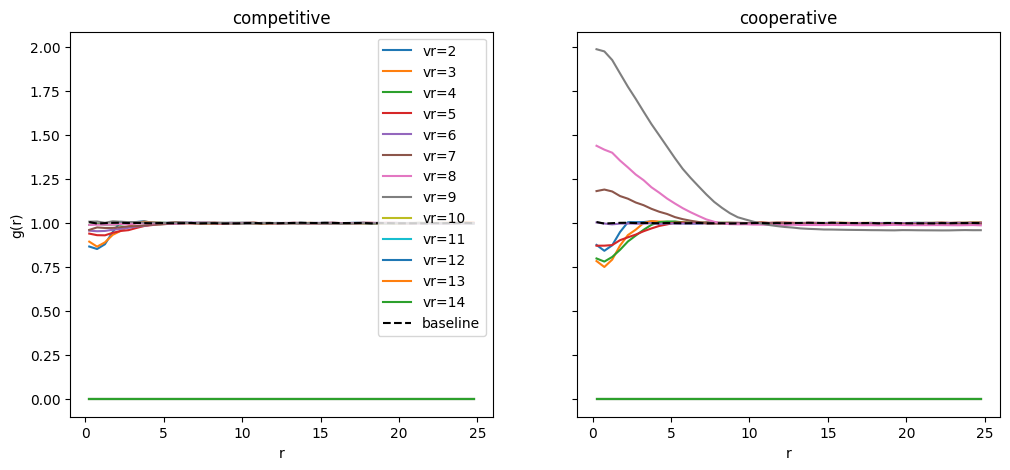

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)

for idx_sd, shared_depletion in enumerate([True, False]):
    for idx_vr, visual_range in enumerate(visual_ranges):
        ax[idx_sd].plot(r_c, grs[idx_sd, :, idx_vr].mean(0), label=f"vr={visual_range}")
    title = 'competitive' if shared_depletion else 'cooperative'
    ax[idx_sd].set_title(title)

for i in  [0,1]:
    ax[i].plot(r_c, np.array(gr_baseline).mean(0), label="baseline", color='black', linestyle='--')

ax[0].legend()
ax[0].set_ylabel("g(r)")
plt.setp(ax, xlabel = "r")

[Text(0.5, 0, 'Visual range'), Text(0.5, 0, 'Visual range')]

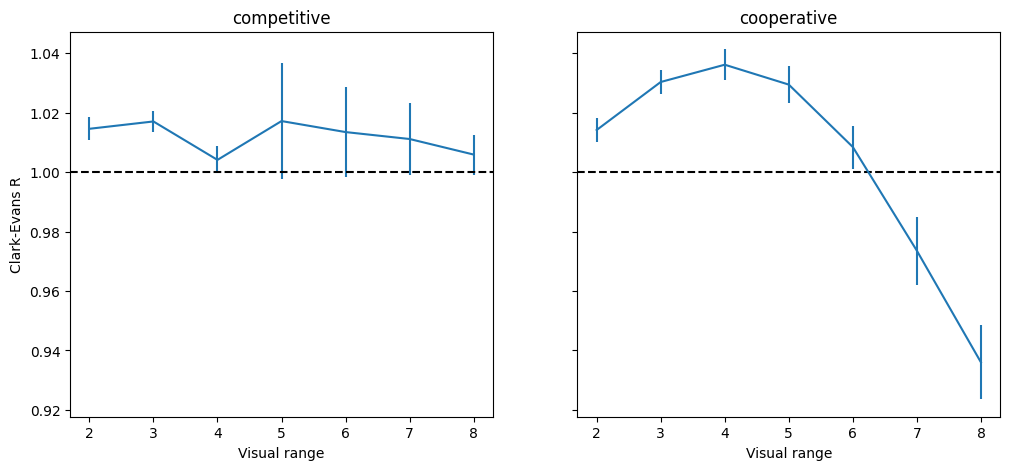

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)
idx_end = -6
for idx_sd, shared_depletion in enumerate([True, False]):
        
    ax[idx_sd].errorbar(visual_ranges[:idx_end], cr_idx[idx_sd].mean(0)[:idx_end], yerr=cr_idx[idx_sd].std(0)[:idx_end], label=f"vr={visual_range}")
    title = 'competitive' if shared_depletion else 'cooperative'
    ax[idx_sd].set_title(title)

    ax[idx_sd].axhline(1, c = 'k', ls = '--')

ax[0].set_ylabel("Clark-Evans R")
plt.setp(ax, xlabel = "Visual range")

#### Episodes = 10k

[Text(0.5, 0, 'r'), Text(0.5, 0, 'r')]

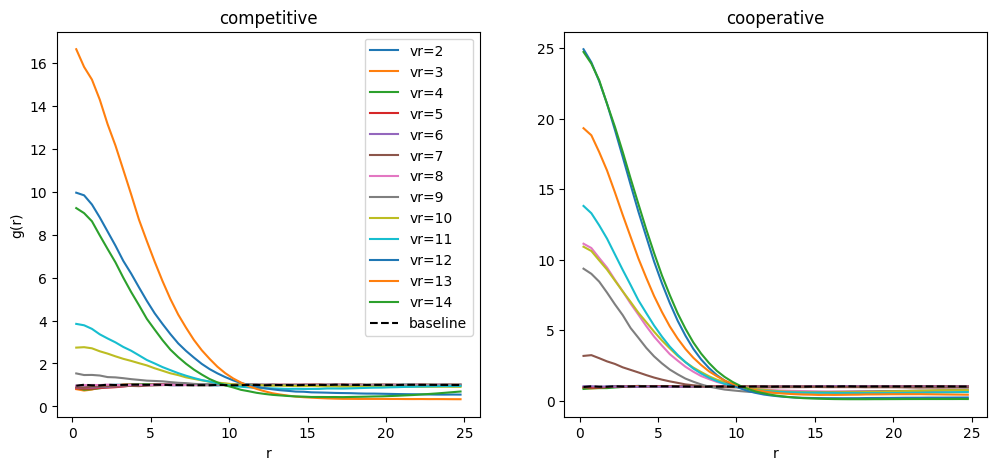

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

for idx_sd, shared_depletion in enumerate([True, False]):
    for idx_vr, visual_range in enumerate(visual_ranges):
        ax[idx_sd].plot(r_c, grs[idx_sd, :, idx_vr].mean(0), label=f"vr={visual_range}")
    title = 'competitive' if shared_depletion else 'cooperative'
    ax[idx_sd].set_title(title)

for i in  [0,1]:
    ax[i].plot(r_c, np.array(gr_baseline).mean(0), label="baseline", color='black', linestyle='--')

ax[0].legend()
ax[0].set_ylabel("g(r)")
plt.setp(ax, xlabel = "r")

[Text(0.5, 0, 'Visual range')]

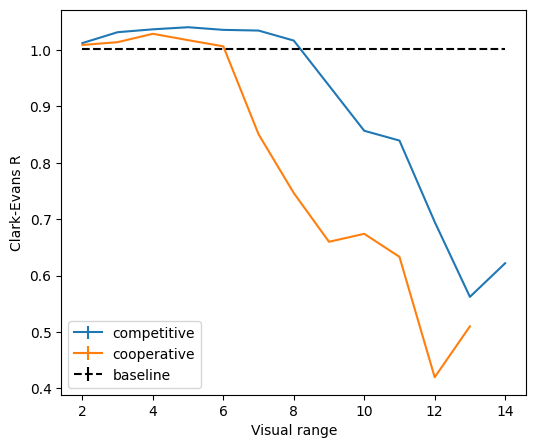

In [ ]:
fig, ax = plt.subplots(figsize=(6,5), sharey=True)

for idx_sd, shared_depletion in enumerate([True, False]):

    label = 'competitive' if shared_depletion else 'cooperative'    

    if idx_sd == 1:
         ax.errorbar(visual_ranges[:-1], cr_idx[idx_sd].mean(0)[:-1], yerr=cr_idx[idx_sd].std(0)[:-1], label=label)
    else:
        ax.errorbar(visual_ranges, cr_idx[idx_sd].mean(0), yerr=cr_idx[idx_sd].std(0), label=label)

ax.errorbar(visual_ranges, np.ones_like(visual_ranges) * np.array(cr_baseline).mean(0), yerr=np.array(cr_baseline).std(0), label="baseline", color='black', linestyle='--')

ax.legend()
ax.set_ylabel("Clark-Evans R")
plt.setp(ax, xlabel = "Visual range")

[Text(0.5, 0, 'Visual range')]

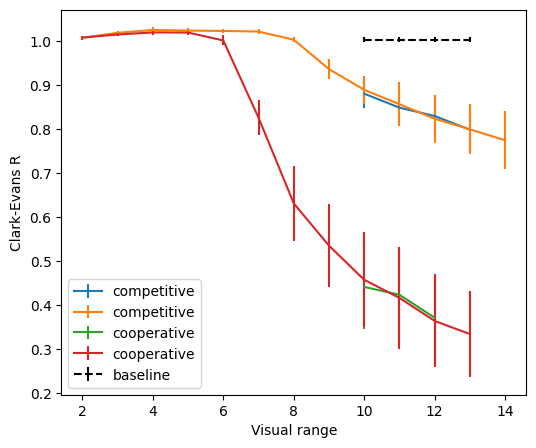

In [ ]:
fig, ax = plt.subplots(figsize=(6,5), sharey=True)

for idx_sd, shared_depletion in enumerate([True, False]):

    label = 'competitive' if shared_depletion else 'cooperative'    

    if idx_sd == 1:
         ax.errorbar(visual_ranges[:-1], cr_idx[idx_sd].mean(0)[:-1], yerr=cr_idx[idx_sd].std(0)[:-1], label=label)
    else:
        ax.errorbar(visual_ranges, cr_idx[idx_sd].mean(0), yerr=cr_idx[idx_sd].std(0), label=label)

    if idx_sd == 1:
         ax.errorbar(vr_1[:-1], cr_1[idx_sd].mean(0)[:-1], yerr=cr_1[idx_sd].std(0)[:-1], label=label)
    else:
        ax.errorbar(vr_1, cr_1[idx_sd].mean(0), yerr=cr_1[idx_sd].std(0), label=label)

ax.errorbar(visual_ranges, np.ones_like(visual_ranges) * np.array(cr_baseline).mean(0), yerr=np.array(cr_baseline).std(0), label="baseline", color='black', linestyle='--')

ax.legend()
ax.set_ylabel("Clark-Evans R")
plt.setp(ax, xlabel = "Visual range")

[Text(0.5, 0, 'Visual range')]

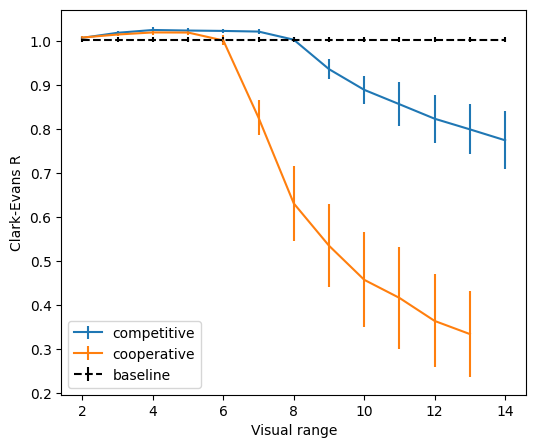

In [ ]:
fig, ax = plt.subplots(figsize=(6,5), sharey=True)

for idx_sd, shared_depletion in enumerate([True, False]):

    label = 'competitive' if shared_depletion else 'cooperative'    

    if idx_sd == 1:
         ax.errorbar(vr_1[:-1], cr_1[idx_sd].mean(0)[:-1], yerr=cr_1[idx_sd].std(0)[:-1], label=label)
    else:
        ax.errorbar(vr_1, cr_1[idx_sd].mean(0), yerr=cr_1[idx_sd].std(0), label=label)

ax.errorbar(vr_1, np.ones_like(vr_1) * np.array(cr_baseline).mean(0), yerr=np.array(cr_baseline).std(0), label="baseline", color='black', linestyle='--')

ax.legend()
ax.set_ylabel("Clark-Evans R")
plt.setp(ax, xlabel = "Visual range")

<matplotlib.lines.Line2D>

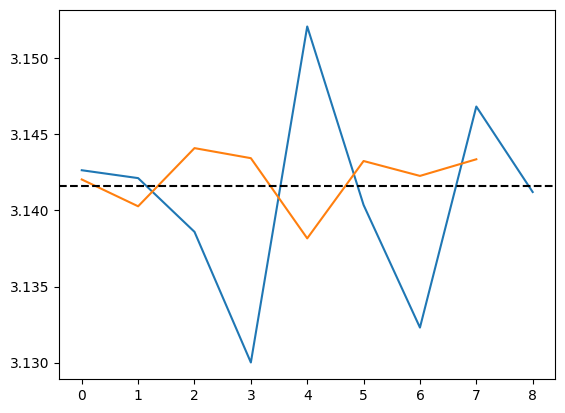

In [ ]:
plt.plot(avg_directions[0].mean(0))
plt.plot(avg_directions[1].mean(0)[:-1])
plt.axhline(np.pi, c = 'k', ls = '--')


### EXP_7_3_1 - v0

In [ ]:
#### MERGING VR and TR

# --- File 1 parameters: VR 4-14, TR 2-5 ---
vr_file1 = np.arange(4, 14)   # VR 4 to 14
tr_file1 = np.arange(2, 6)    # TR 2 to 5

# --- File 2 parameters: VR 1-8, TR 1-5 ---
vr_file2 = np.arange(1, 9)    # VR 1 to 8
tr_file2 = np.arange(1, 6)    # TR 1 to 5

# --- Merged output grid (tau_reward > 1 only) ---
tr_merged = np.arange(2, 6)   # TR 2-5
vr_merged = np.arange(1, 14)  # VR 1-13

episodes_learning = 10000
episodes = 1
time_ep = 15000
save_position_from_ep = 10000

dr = 0.5
n_bins = int(L / 2 / dr)
gr_loop = np.zeros((2, len(vr_merged), len(tr_merged), n_bins))
cr_loop = np.zeros((2, len(vr_merged), len(tr_merged)))

n_state = int(np.prod(state_space))

for idx_sd, shared_depletion in enumerate([True, False]):

    # Load File 1 (VR 4-14, TR 2-5)
    fn1 = f"_shared_{shared_depletion}_tau_{tau}_tauR_{tr_file1[0]}_to_{tr_file1[-1]}_vr_{vr_file1[0]}_to_{vr_file1[-1]}_ep_{episodes_learning}.npy"
    mats1 = np.load(os.path.join(out_dir, "h_matrix" + fn1))
    mats1 = mats1.reshape(len(tr_file1), len(vr_file1), num_agents, 2, n_state)

    # Load File 2 (VR 1-8, TR 1-5)
    fn2 = f"_shared_{shared_depletion}_tau_{tau}_tauR_{tr_file2[0]}_to_{tr_file2[-1]}_vr_{vr_file2[0]}_to_{vr_file2[-1]}_ep_{episodes_learning}.npy"
    mats2 = np.load(os.path.join(out_dir, "h_matrix" + fn2))
    mats2 = mats2.reshape(len(tr_file2), len(vr_file2), num_agents, 2, n_state)

    for idx_vr, visual_range in enumerate(tqdm(vr_merged)):
        for idx_tr, tau_reward in enumerate(tr_merged):

            sources = []
            if visual_range in vr_file1 and tau_reward in tr_file1:
                i_vr1 = int(np.where(vr_file1 == visual_range)[0][0])
                i_tr1 = int(np.where(tr_file1 == tau_reward)[0][0])
                sources.append(mats1[i_tr1, i_vr1])
            if visual_range in vr_file2 and tau_reward in tr_file2:
                i_vr2 = int(np.where(vr_file2 == visual_range)[0][0])
                i_tr2 = int(np.where(tr_file2 == tau_reward)[0][0])
                sources.append(mats2[i_tr2, i_vr2])

            gr_accum = np.zeros(n_bins)
            cr_accum = 0.0
            for mats_run in sources:
                rews, posr, directions = run_simul_collective(
                    episodes=episodes, time_ep=time_ep, runs=1,
                    h_0=mats_run[np.newaxis], initial_h_0=True,
                    Nt=Nt, L=L, r=r, tau=tau, agent_step=agent_step,
                    num_agents=num_agents, visual_range=visual_range,
                    visual_angle=visual_angle, shared_depletion=shared_depletion,
                    tau_reward=tau_reward, upd_pos_method='RND',
                    turn_angle=visual_angle,
                    save_position_from_ep=save_position_from_ep,
                )
                r_c, gr_r, cr_r = compute_gr_all_runs(posr, L=L, dr=0.5)
                gr_accum += gr_r[0]
                cr_accum += cr_r[0]

            if sources:
                gr_loop[idx_sd, idx_vr, idx_tr] = gr_accum / len(sources)
                cr_loop[idx_sd, idx_vr, idx_tr] = cr_accum / len(sources)


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

<matplotlib.legend.Legend>

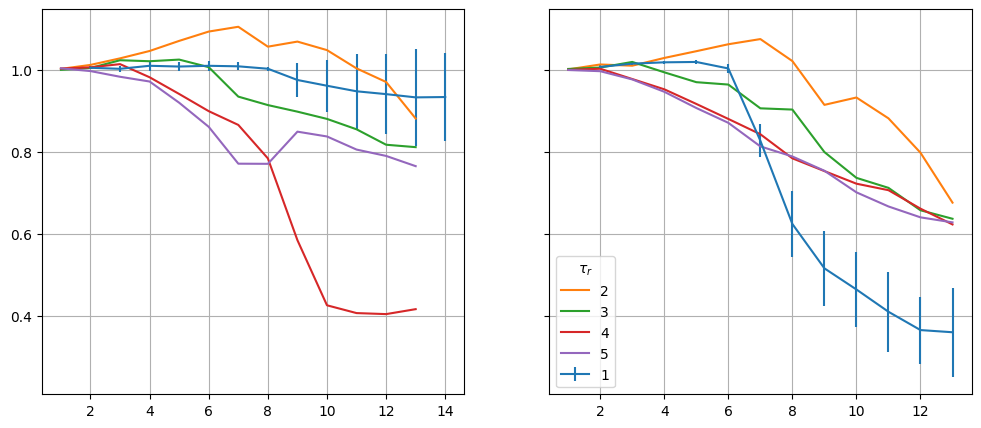

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)
for idx_sd, shared_depletion in enumerate([True, False]):

    if idx_sd == 1:
        ax[idx_sd].errorbar(visual_ranges[:-1], cr_idx[idx_sd].mean(0)[:-1], yerr=cr_idx[idx_sd].std(0)[:-1], label=1)
    else:
        ax[idx_sd].errorbar(visual_ranges, cr_idx[idx_sd].mean(0), yerr=cr_idx[idx_sd].std(0), label=1)

    
    ax[idx_sd].plot(vr_merged, cr_loop[idx_sd], label = tr_merged)

    ax[idx_sd].grid()
plt.legend(title = r"$\tau_r$")

[Text(0.5, 0, 'r'), Text(0.5, 0, 'r'), Text(0.5, 0, 'r'), Text(0.5, 0, 'r')]

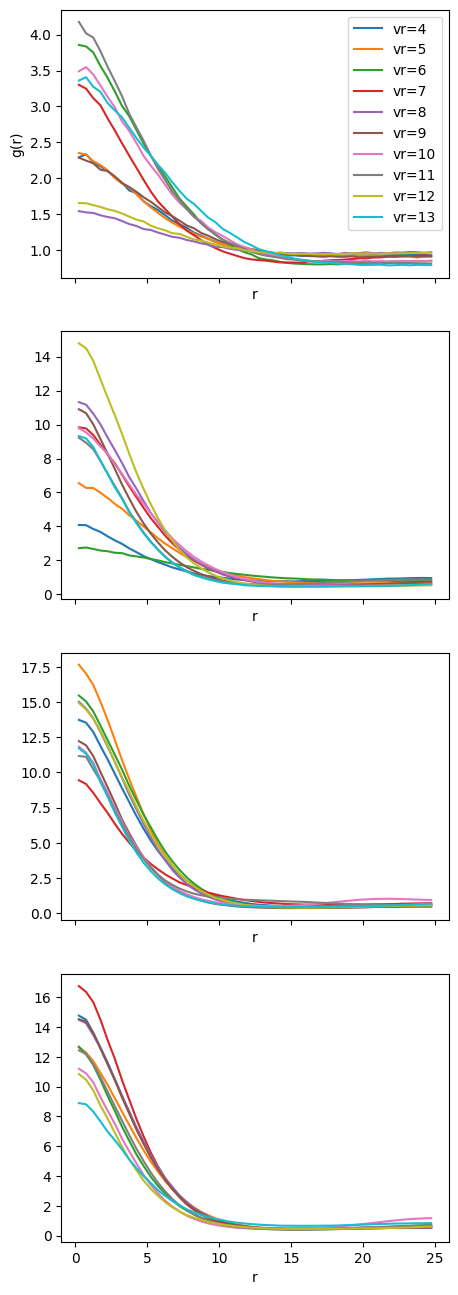

In [ ]:
fig, ax = plt.subplots(len(tau_rewards_1), 1, figsize=(5, 4*len(tau_rewards_1)), sharex=True)

for idx_tau, tau_reward in enumerate(tau_rewards_1):
    for idx_vr, visual_range in enumerate(visual_ranges_1):
        ax[idx_tau].plot(r_c, gr_1[idx_tau, idx_vr], label=f"vr={visual_range}")

ax[0].legend()
ax[0].set_ylabel("g(r)")
plt.setp(ax, xlabel = "r")

### EXP 7_3_1 - v1

##### With targets

###### Running and saving positions for longer times

In [ ]:
episodes = 1
time_ep = 15000
save_position_from_ep = time_ep - 5000


episodes_learning = 10000

taus_reward = np.arange(1, 10)   
visual_ranges = np.arange(2, 13) 
n_runs = 80


out_dir_results = os.path.join(out_dir, f"results")
os.makedirs(out_dir_results, exist_ok=True)

num_agents = 25
tau = 4
taus_reward = np.arange(2, 10)   
visual_ranges = np.arange(2, 13) 



for idx_sd, shared_depletion in enumerate([True, False]):

    # Share false is not yet finished
    # if idx_sd == 1: break

    for idx_tr, tau_reward in enumerate(tqdm(taus_reward)):
        for idx_vr, visual_range in enumerate(tqdm(visual_ranges)):

            if num_agents == 50:
                file_results = f"_shared_{shared_depletion}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}_ep_{episodes_learning}_simul_to_{time_ep}_Nt_{Nt}.npy"
                file_name = f"_shared_{shared_depletion}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}_ep_{episodes_learning}.npy"
            else:
                file_results = f"_shared_{shared_depletion}_numag_{num_agents}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}_ep_{episodes_learning}_simul_to_{time_ep}_Nt_{Nt}.npy"
                file_name = f"_shared_{shared_depletion}_numag_{num_agents}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}_ep_{episodes_learning}.npy"

            if os.path.exists(os.path.join(out_dir_results, f"rews"+file_results)):
                continue            

                                
            h_matrix_path = os.path.join(out_dir, 
                                        f"h_matrix"+file_name)
            
            try:
                mats = np.load(h_matrix_path)
                if len(mats.shape) > 4:
                    mats = mats[:, idx_vr] # I messed up saving files for tau = 2 and num_agents = 10, 25 and 50, for these, every file has all VRs
                # n_runs = mats.shape[0]

            except:
                print(f"File not found: {h_matrix_path}, skipping.")
                continue


            rews, posr, directions = run_simul_collective(episodes = episodes, time_ep = time_ep, runs = n_runs, h_0= mats, initial_h_0=True,
                                            Nt = Nt, L = L, r = r, tau = tau, agent_step = agent_step, num_agents = num_agents,
                                        visual_range = visual_range, visual_angle = visual_angle, 
                                        shared_depletion = shared_depletion, tau_reward = tau_reward, upd_pos_method = 'RND', turn_angle = visual_angle,
                                        save_position_from_ep = save_position_from_ep)
            


            np.save(os.path.join(out_dir_results, f"rews"+file_results), rews)
            np.save(os.path.join(out_dir_results, f"pos"+file_results), posr)
            np.save(os.path.join(out_dir_results, f"directions"+file_results), directions)            

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

...

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

###### Computing metrics

In [ ]:
num_agents = 25
tau = 4
taus_reward = np.arange(2, 10)   
visual_ranges = np.arange(2, 13) 


episodes = 1
time_ep = 15000
save_position_from_ep = time_ep - 5000

episodes_learning = 10000

n_runs = 40


dr = 0.5
n_bins = int(L / 2 / dr)
avg_grs = np.zeros((2, len(taus_reward), len(visual_ranges), n_bins))
avg_cr_idx = np.zeros((2, len(taus_reward), len(visual_ranges)))
std_cr_idx = np.zeros((2, len(taus_reward), len(visual_ranges)))
avg_polarization = np.zeros((2, len(taus_reward), len(visual_ranges)))
milling_orders = np.zeros((2, len(taus_reward), len(visual_ranges)))
for idx_sd, shared_depletion in enumerate([True, False]):    

    # Share false is not yet finished
    # if idx_sd == 1: break

    for idx_tr, tau_reward in enumerate(tqdm(taus_reward)):
        for idx_vr, visual_range in enumerate(tqdm(visual_ranges)):

            if avg_cr_idx[idx_sd, idx_tr,idx_vr] != 0:
                continue

            if num_agents == 50:
                file_results = f"_shared_{shared_depletion}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}_ep_{episodes_learning}_simul_to_{time_ep}_Nt_{Nt}.npy"
            else:
                file_results = f"_shared_{shared_depletion}_numag_{num_agents}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}_ep_{episodes_learning}_simul_to_{time_ep}_Nt_{Nt}.npy"
                
            try:
                rews = np.load(os.path.join(out_dir_results, f"rews"+file_results))
                posr = np.load(os.path.join(out_dir_results, f"pos"+file_results))
                directions = np.load(os.path.join(out_dir_results, f"directions"+file_results))
            except:
                continue
            
            r_c, gr_runs, cr_runs = compute_gr_all_runs(posr, L=L, dr=0.5)
            avg_grs[idx_sd, idx_tr,idx_vr] = gr_runs.mean(0)
            avg_cr_idx[idx_sd, idx_tr, idx_vr] = cr_runs.mean()
            std_cr_idx[idx_sd, idx_tr, idx_vr] = cr_runs.std()
            

            M = milling_order_numba(
                            positions=posr[:, 0],
                            directions=directions[:,0],
                            step_size=1.0
                        )
            milling_orders[idx_sd, idx_tr, idx_vr] = M.mean()


            avg_polarization[idx_sd,idx_tr, idx_vr] = polarisation_per_run(directions[:,0]).mean()

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

...

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

###### PLotting

N = 10

<matplotlib.legend.Legend>

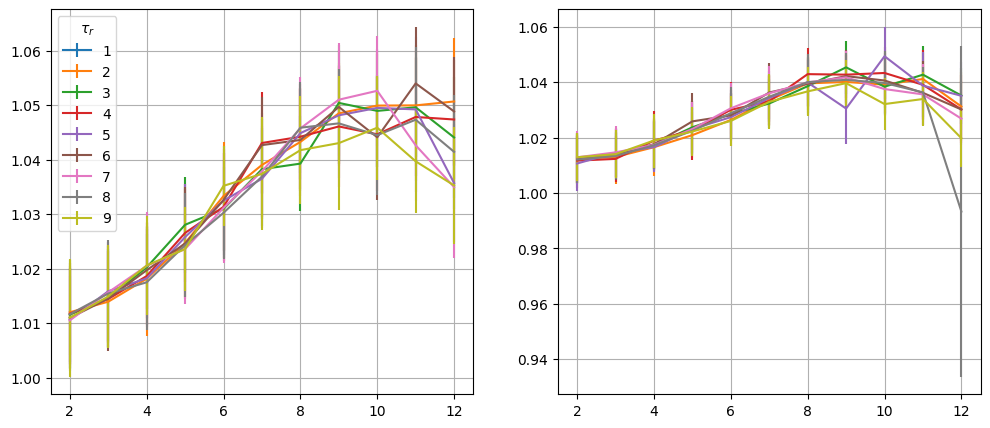

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
for idx_sd, shared_depletion in enumerate([True, False]):    
    for idx_tr, tau_reward in enumerate(taus_reward):

        cr_plot = avg_cr_idx[idx_sd, idx_tr]

        # ax[idx_sd].plot(visual_ranges[cr_plot != 0], cr_plot[cr_plot != 0], label=f"tauR={tau_reward}")

        ax[idx_sd].errorbar(visual_ranges[cr_plot != 0], cr_plot[cr_plot != 0], yerr=std_cr_idx[idx_sd, idx_tr][cr_plot != 0], label=f"{tau_reward}")

    ax[idx_sd].grid()
ax[0].legend(title = r"$\tau_r$")

''

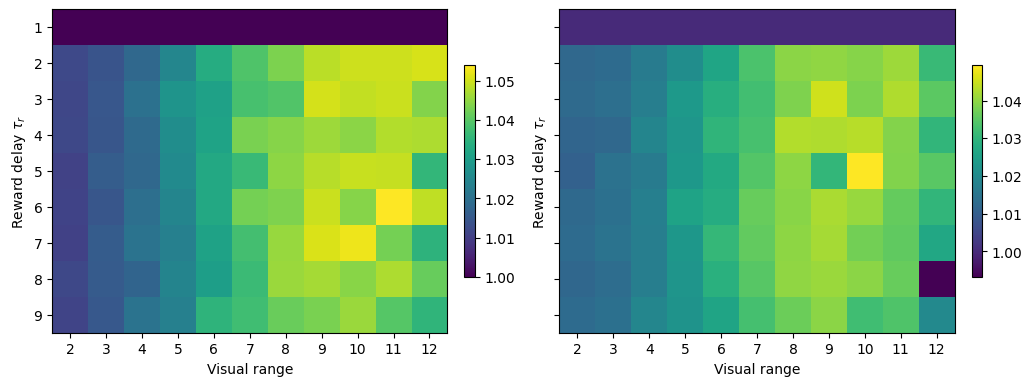

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)
for idx_sd, shared_depletion in enumerate([True, False]):

    avg_cr_idx[avg_cr_idx == 0] = 1
    
    ax[idx_sd].matshow(avg_cr_idx[idx_sd])
    # put x axis on bottom
    ax[idx_sd].xaxis.set_ticks_position('bottom')

plt.setp(ax, 
         xticks=np.arange(len(visual_ranges)), xticklabels=visual_ranges, yticks=np.arange(len(taus_reward)), yticklabels=taus_reward,
         xlabel = "Visual range", ylabel = r"Reward delay $\tau_r$"
         )

# add colorbar to both subplots
cbar1 = fig.colorbar(ax[1].images[0], ax=ax[1], orientation='vertical', fraction=0.025, pad=0.04)
cbar2 = fig.colorbar(ax[0].images[0], ax=ax[0], orientation='vertical', fraction=0.025, pad=0.04)
;

N = 25

$\tau = 2$

[Text(0.5, 0, 'Visual range'), Text(0.5, 0, 'Visual range')]

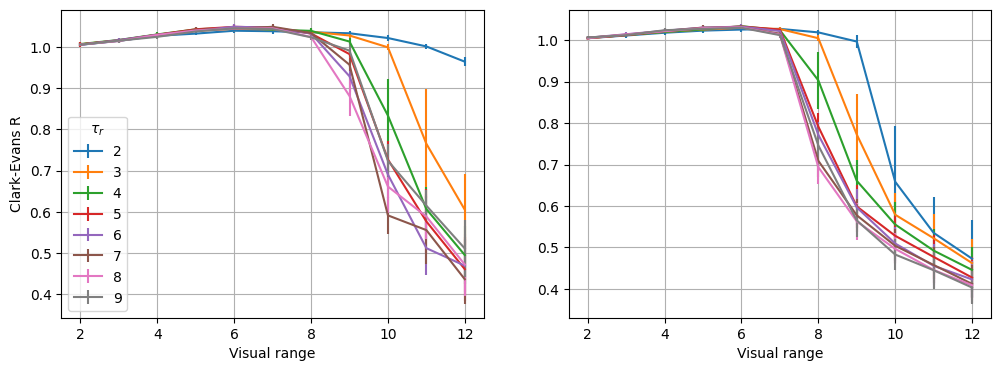

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(2*6, 1*4))
for idx_sd, shared_depletion in enumerate([True, False]):    
    for idx_tr, tau_reward in enumerate(taus_reward):

        if idx_tr == 0: continue

        cr_plot = avg_cr_idx[idx_sd, idx_tr]

        # ax[idx_sd].plot(visual_ranges[cr_plot != 0], cr_plot[cr_plot != 0], label=f"tauR={tau_reward}")

        ax[idx_sd].errorbar(visual_ranges[cr_plot != 0], cr_plot[cr_plot != 0], yerr=std_cr_idx[idx_sd, idx_tr][cr_plot != 0], label=f"{tau_reward}")

    ax[idx_sd].grid()
ax[0].legend(title = r"$\tau_r$")
ax[0].set_ylabel("Clark-Evans R")
plt.setp(ax, xlabel = "Visual range")

''

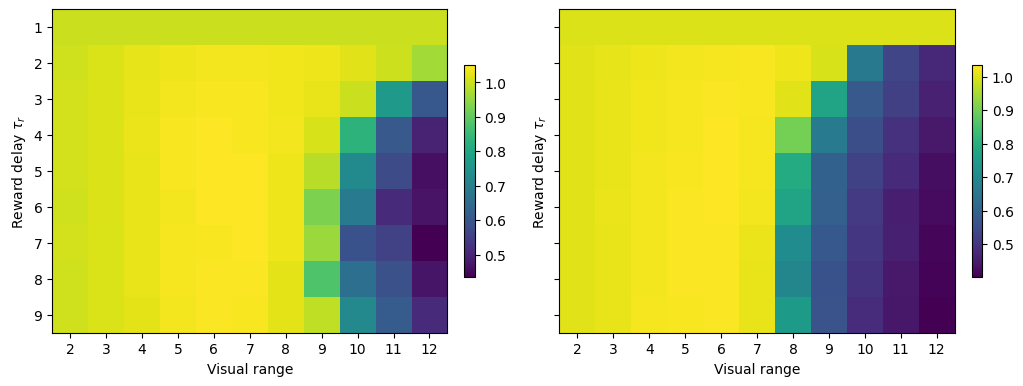

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)
for idx_sd, shared_depletion in enumerate([True, False]):

    avg_cr_idx[avg_cr_idx == 0] = 1
    
    ax[idx_sd].matshow(avg_cr_idx[idx_sd])
    # put x axis on bottom
    ax[idx_sd].xaxis.set_ticks_position('bottom')

plt.setp(ax, 
         xticks=np.arange(len(visual_ranges)), xticklabels=visual_ranges, yticks=np.arange(len(taus_reward)), yticklabels=taus_reward,
         xlabel = "Visual range", ylabel = r"Reward delay $\tau_r$"
         )

# add colorbar to both subplots
cbar1 = fig.colorbar(ax[1].images[0], ax=ax[1], orientation='vertical', fraction=0.025, pad=0.04)
cbar2 = fig.colorbar(ax[0].images[0], ax=ax[0], orientation='vertical', fraction=0.025, pad=0.04)
;

''

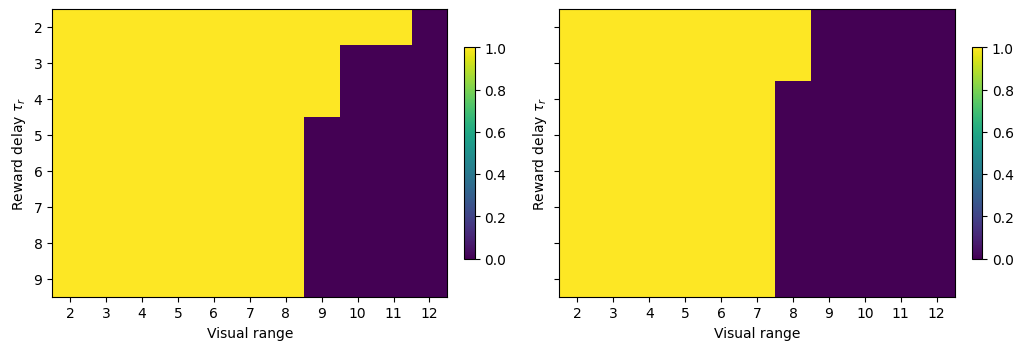

In [ ]:
phase_t = avg_cr_idx >= 1

fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)
for idx_sd, shared_depletion in enumerate([True, False]):

    
    
    ax[idx_sd].matshow(phase_t[idx_sd, 1:])
    # put x axis on bottom
    ax[idx_sd].xaxis.set_ticks_position('bottom')

plt.setp(ax, 
         xticks=np.arange(len(visual_ranges)), xticklabels=visual_ranges, yticks=np.arange(len(taus_reward)-1), yticklabels=taus_reward[1:],
         xlabel = "Visual range", ylabel = r"Reward delay $\tau_r$"
         )

# add colorbar to both subplots
cbar1 = fig.colorbar(ax[1].images[0], ax=ax[1], orientation='vertical', fraction=0.025, pad=0.04)
cbar2 = fig.colorbar(ax[0].images[0], ax=ax[0], orientation='vertical', fraction=0.025, pad=0.04)
;

$\tau = 4$

[Text(0.5, 0, 'Visual range'), Text(0.5, 0, 'Visual range')]

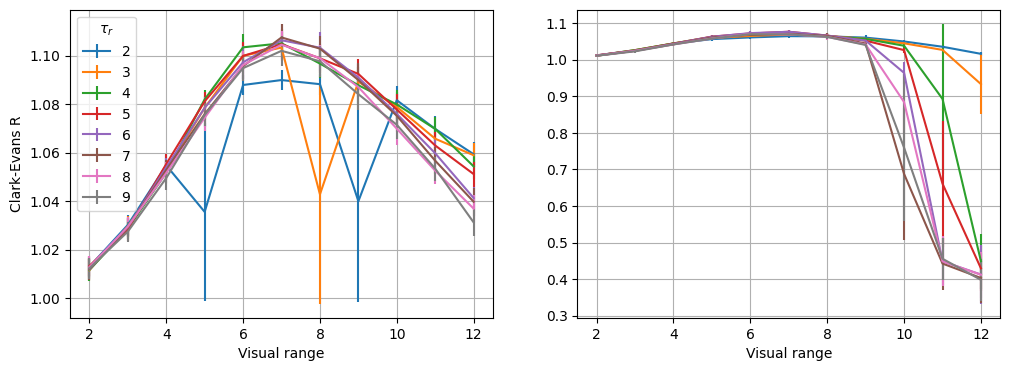

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(2*6, 1*4))
for idx_sd, shared_depletion in enumerate([True, False]):    
    for idx_tr, tau_reward in enumerate(taus_reward):


        cr_plot = avg_cr_idx[idx_sd, idx_tr]

        # ax[idx_sd].plot(visual_ranges[cr_plot != 0], cr_plot[cr_plot != 0], label=f"tauR={tau_reward}")

        ax[idx_sd].errorbar(visual_ranges[cr_plot != 0], cr_plot[cr_plot != 0], yerr=std_cr_idx[idx_sd, idx_tr][cr_plot != 0], label=f"{tau_reward}")

    ax[idx_sd].grid()
ax[0].legend(title = r"$\tau_r$")
ax[0].set_ylabel("Clark-Evans R")
plt.setp(ax, xlabel = "Visual range")

''

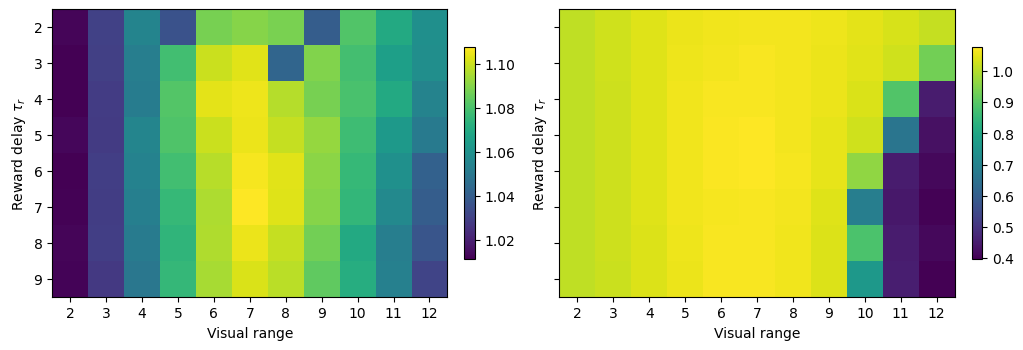

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)
for idx_sd, shared_depletion in enumerate([True, False]):

    avg_cr_idx[avg_cr_idx == 0] = 1
    
    ax[idx_sd].matshow(avg_cr_idx[idx_sd])
    # put x axis on bottom
    ax[idx_sd].xaxis.set_ticks_position('bottom')

plt.setp(ax, 
         xticks=np.arange(len(visual_ranges)), xticklabels=visual_ranges, yticks=np.arange(len(taus_reward)), yticklabels=taus_reward,
         xlabel = "Visual range", ylabel = r"Reward delay $\tau_r$"
         )

# add colorbar to both subplots
cbar1 = fig.colorbar(ax[1].images[0], ax=ax[1], orientation='vertical', fraction=0.025, pad=0.04)
cbar2 = fig.colorbar(ax[0].images[0], ax=ax[0], orientation='vertical', fraction=0.025, pad=0.04)
;

$\tau = 6$

[Text(0.5, 0, 'Visual range'), Text(0.5, 0, 'Visual range')]

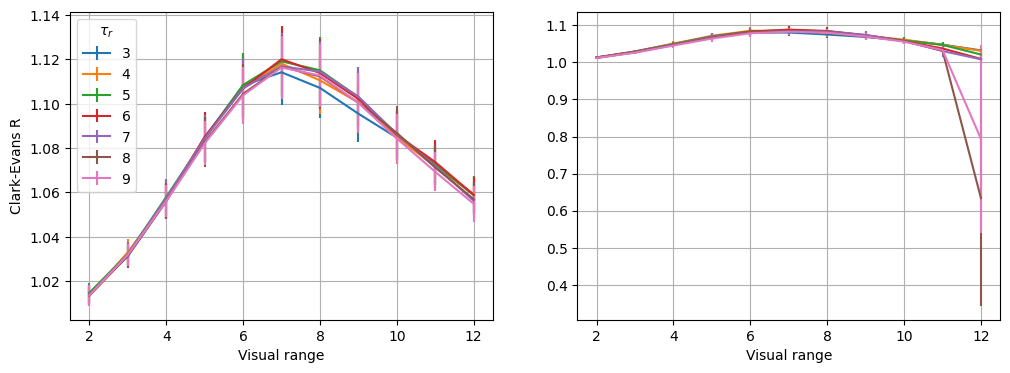

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(2*6, 1*4))
for idx_sd, shared_depletion in enumerate([True, False]):    
    for idx_tr, tau_reward in enumerate(taus_reward):

        if idx_tr == 0: continue

        cr_plot = avg_cr_idx[idx_sd, idx_tr]

        # ax[idx_sd].plot(visual_ranges[cr_plot != 0], cr_plot[cr_plot != 0], label=f"tauR={tau_reward}")

        ax[idx_sd].errorbar(visual_ranges[cr_plot != 0], cr_plot[cr_plot != 0], yerr=std_cr_idx[idx_sd, idx_tr][cr_plot != 0], label=f"{tau_reward}")

    ax[idx_sd].grid()
ax[0].legend(title = r"$\tau_r$")
ax[0].set_ylabel("Clark-Evans R")
plt.setp(ax, xlabel = "Visual range")

''

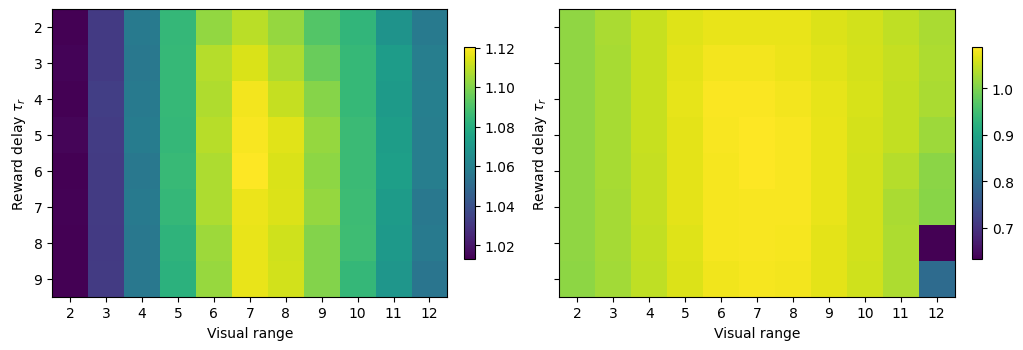

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)
for idx_sd, shared_depletion in enumerate([True, False]):

    avg_cr_idx[avg_cr_idx == 0] = 1
    
    ax[idx_sd].matshow(avg_cr_idx[idx_sd])
    # put x axis on bottom
    ax[idx_sd].xaxis.set_ticks_position('bottom')

plt.setp(ax, 
         xticks=np.arange(len(visual_ranges)), xticklabels=visual_ranges, yticks=np.arange(len(taus_reward)), yticklabels=taus_reward,
         xlabel = "Visual range", ylabel = r"Reward delay $\tau_r$"
         )

# add colorbar to both subplots
cbar1 = fig.colorbar(ax[1].images[0], ax=ax[1], orientation='vertical', fraction=0.025, pad=0.04)
cbar2 = fig.colorbar(ax[0].images[0], ax=ax[0], orientation='vertical', fraction=0.025, pad=0.04)
;

''

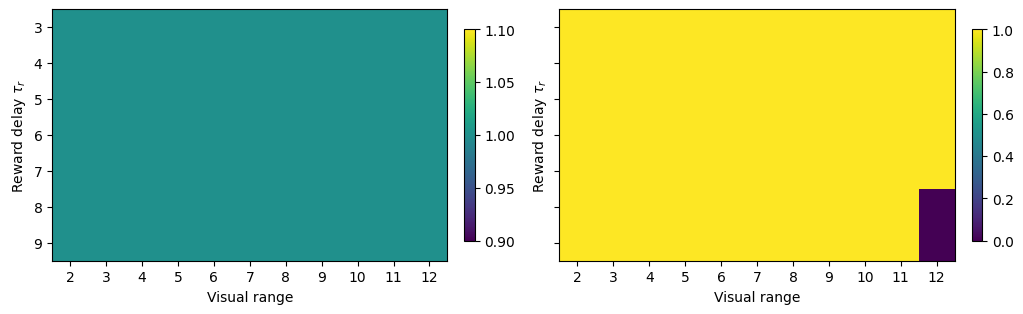

In [ ]:
phase_t = avg_cr_idx >= 1

fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)
for idx_sd, shared_depletion in enumerate([True, False]):

    
    
    ax[idx_sd].matshow(phase_t[idx_sd, 1:])
    # put x axis on bottom
    ax[idx_sd].xaxis.set_ticks_position('bottom')

plt.setp(ax, 
         xticks=np.arange(len(visual_ranges)), xticklabels=visual_ranges, yticks=np.arange(len(taus_reward)-1), yticklabels=taus_reward[1:],
         xlabel = "Visual range", ylabel = r"Reward delay $\tau_r$"
         )

# add colorbar to both subplots
cbar1 = fig.colorbar(ax[1].images[0], ax=ax[1], orientation='vertical', fraction=0.025, pad=0.04)
cbar2 = fig.colorbar(ax[0].images[0], ax=ax[0], orientation='vertical', fraction=0.025, pad=0.04)
;

N = 50

<matplotlib.legend.Legend>

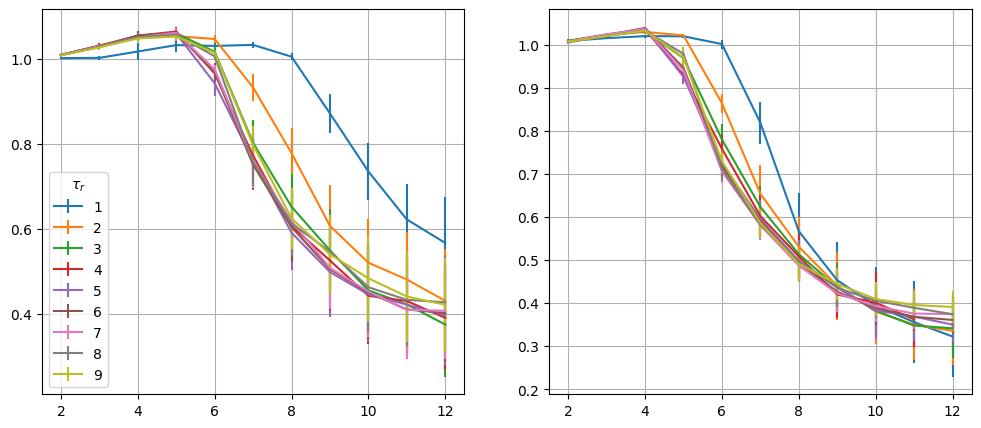

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
for idx_sd, shared_depletion in enumerate([True, False]):    
    for idx_tr, tau_reward in enumerate(taus_reward):

        cr_plot = avg_cr_idx[idx_sd, idx_tr]

        # ax[idx_sd].plot(visual_ranges[cr_plot != 0], cr_plot[cr_plot != 0], label=f"tauR={tau_reward}")

        ax[idx_sd].errorbar(visual_ranges[cr_plot != 0], cr_plot[cr_plot != 0], yerr=std_cr_idx[idx_sd, idx_tr][cr_plot != 0], label=f"{tau_reward}")

    ax[idx_sd].grid()
ax[0].legend(title = r"$\tau_r$")

''

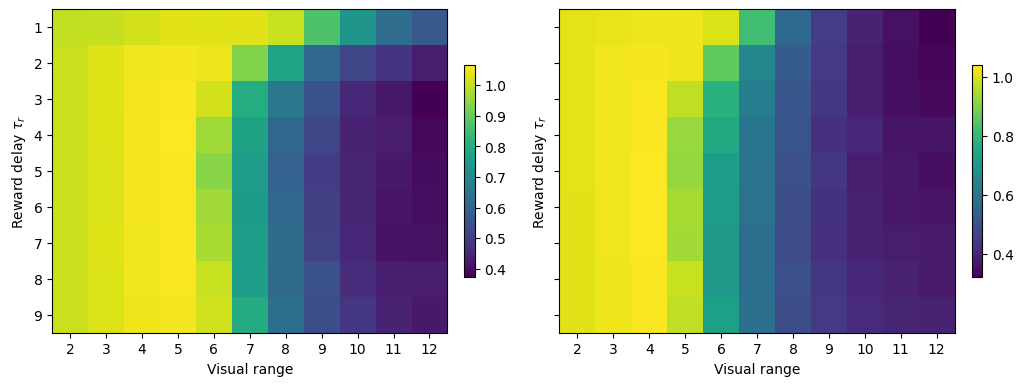

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)
for idx_sd, shared_depletion in enumerate([True, False]):

    ax[idx_sd].matshow(avg_cr_idx[idx_sd])
    # put x axis on bottom
    ax[idx_sd].xaxis.set_ticks_position('bottom')

plt.setp(ax, 
         xticks=np.arange(len(visual_ranges)), xticklabels=visual_ranges, yticks=np.arange(len(taus_reward)), yticklabels=taus_reward,
         xlabel = "Visual range", ylabel = r"Reward delay $\tau_r$"
         )

# add colorbar to both subplots
cbar1 = fig.colorbar(ax[1].images[0], ax=ax[1], orientation='vertical', fraction=0.025, pad=0.04)
cbar2 = fig.colorbar(ax[0].images[0], ax=ax[0], orientation='vertical', fraction=0.025, pad=0.04)
;

[Text(0.5, 0, 'Visual range'), Text(0.5, 0, 'Visual range')]

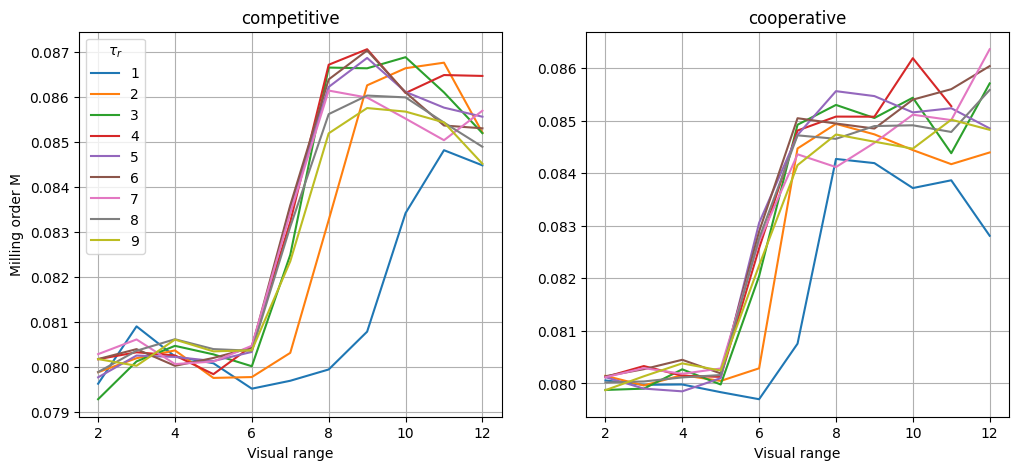

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
for idx_sd, shared_depletion in enumerate([True, False]):    
    for idx_tr, tau_reward in enumerate(taus_reward):

        cr_plot = milling_orders[idx_sd, idx_tr]

        ax[idx_sd].plot(visual_ranges[cr_plot != 0], cr_plot[cr_plot != 0], label=f"{tau_reward}")

        title = 'competitive' if shared_depletion else 'cooperative'
        ax[idx_sd].set_title(title)

    ax[idx_sd].grid()
ax[0].legend(title = r"$\tau_r$")
ax[0].set_ylabel("Milling order M")
plt.setp(ax, xlabel = "Visual range")

[Text(0.5, 0, 'Visual range'), Text(0.5, 0, 'Visual range')]

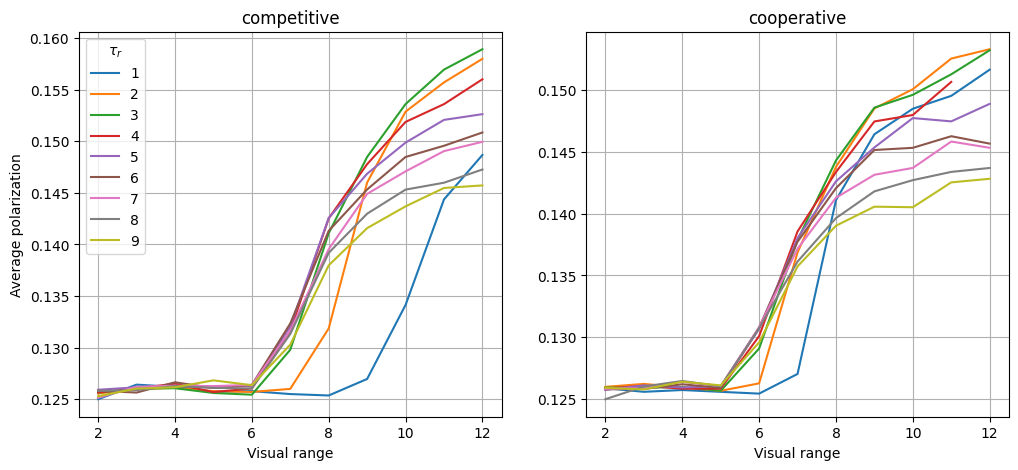

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
for idx_sd, shared_depletion in enumerate([True, False]):    
    for idx_tr, tau_reward in enumerate(taus_reward):

        cr_plot = avg_polarization[idx_sd, idx_tr]

        ax[idx_sd].plot(visual_ranges[cr_plot != 0], cr_plot[cr_plot != 0], label=f"{tau_reward}")

        title = 'competitive' if shared_depletion else 'cooperative'
        ax[idx_sd].set_title(title)

    ax[idx_sd].grid()
ax[0].legend(title = r"$\tau_r$")
ax[0].set_ylabel("Average polarization")
plt.setp(ax, xlabel = "Visual range")

<matplotlib.legend.Legend>

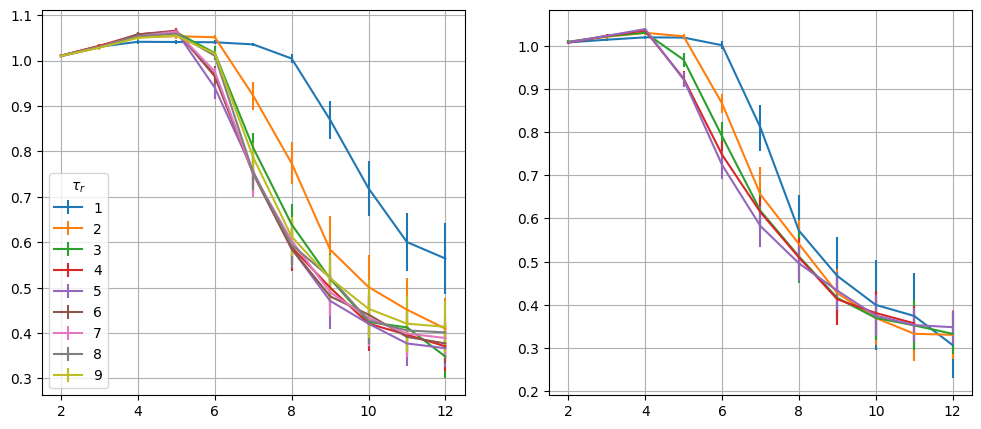

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
for idx_sd, shared_depletion in enumerate([True, False]):    
    for idx_tr, tau_reward in enumerate(taus_reward):

        cr_plot = avg_cr_idx[idx_sd, idx_tr]

        # ax[idx_sd].plot(visual_ranges[cr_plot != 0], cr_plot[cr_plot != 0], label=f"tauR={tau_reward}")

        ax[idx_sd].errorbar(visual_ranges[cr_plot != 0], cr_plot[cr_plot != 0], yerr=std_cr_idx[idx_sd, idx_tr][cr_plot != 0], label=f"{tau_reward}")

    ax[idx_sd].grid()
ax[0].legend(title = r"$\tau_r$")

''

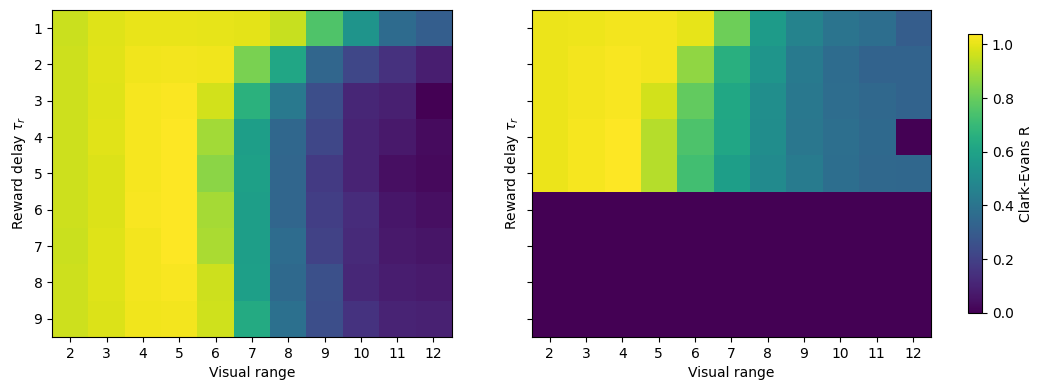

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)
for idx_sd, shared_depletion in enumerate([True, False]):

    ax[idx_sd].matshow(avg_cr_idx[idx_sd])
    # put x axis on bottom
    ax[idx_sd].xaxis.set_ticks_position('bottom')

plt.setp(ax, 
         xticks=np.arange(len(visual_ranges)), xticklabels=visual_ranges, yticks=np.arange(len(taus_reward)), yticklabels=taus_reward,
         xlabel = "Visual range", ylabel = r"Reward delay $\tau_r$"
         )

# add colorbar to both subplots
cbar1 = fig.colorbar(ax[1].images[0], ax=ax[1], orientation='vertical', fraction=0.025, pad=0.04)
cbar2 = fig.colorbar(ax[0].images[0], ax=ax[0], orientation='vertical', fraction=0.025, pad=0.04)
;

[Text(0.5, 0, 'Visual range'), Text(0.5, 0, 'Visual range')]

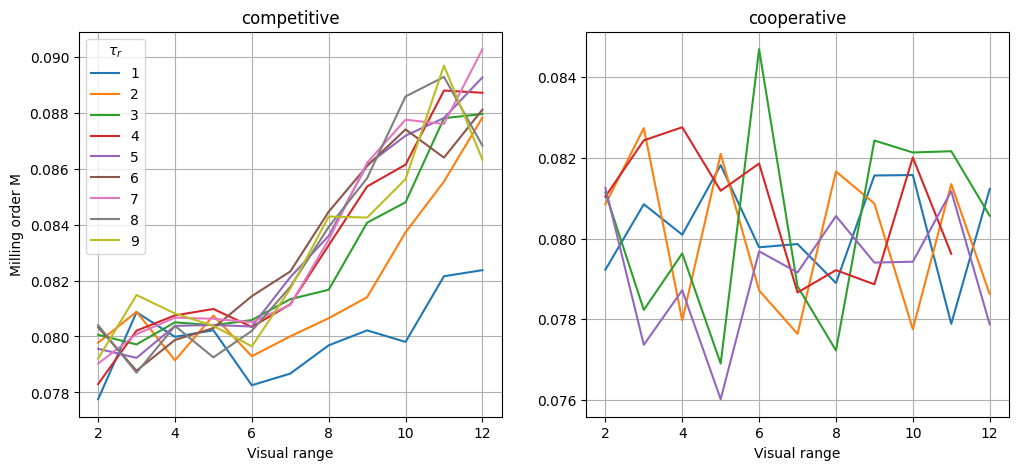

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
for idx_sd, shared_depletion in enumerate([True, False]):    
    for idx_tr, tau_reward in enumerate(taus_reward):

        cr_plot = milling_orders[idx_sd, idx_tr]

        ax[idx_sd].plot(visual_ranges[cr_plot != 0], cr_plot[cr_plot != 0], label=f"{tau_reward}")

        title = 'competitive' if shared_depletion else 'cooperative'
        ax[idx_sd].set_title(title)

    ax[idx_sd].grid()
ax[0].legend(title = r"$\tau_r$")
ax[0].set_ylabel("Milling order M")
plt.setp(ax, xlabel = "Visual range")

In [ ]:
avg_directions.shape

(2, 9, 11)

[Text(0.5, 0, 'Visual range'), Text(0.5, 0, 'Visual range')]

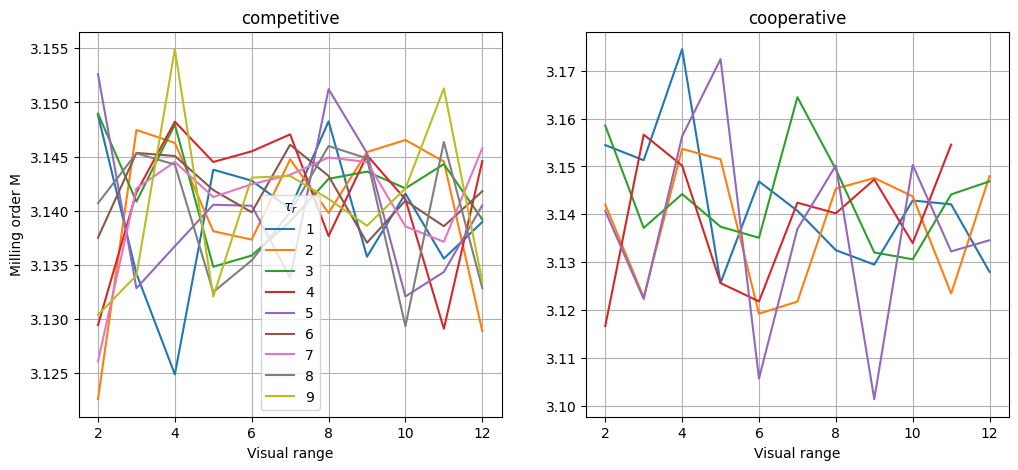

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
for idx_sd, shared_depletion in enumerate([True, False]):    
    for idx_tr, tau_reward in enumerate(taus_reward):

        cr_plot = avg_directions[idx_sd, idx_tr]

        ax[idx_sd].plot(visual_ranges[cr_plot != 0], cr_plot[cr_plot != 0], label=f"{tau_reward}")

        title = 'competitive' if shared_depletion else 'cooperative'
        ax[idx_sd].set_title(title)

    ax[idx_sd].grid()
ax[0].legend(title = r"$\tau_r$")
ax[0].set_ylabel("Average direction")
plt.setp(ax, xlabel = "Visual range")

##### Without targets

In [ ]:
episodes = 1
time_ep = 15000
save_position_from_ep = time_ep - 3000

# WE set this by hand so there is not reward agents
Nt = 0

episodes_learning = 10000

taus_reward = np.arange(1, 10)   
visual_ranges = np.arange(2, 13) 
n_runs = 40

dr = 0.5
n_bins = int(L / 2 / dr)
avg_grs_no_rew = np.zeros((2, len(taus_reward), len(visual_ranges), n_bins))
avg_cr_idx_no_rew = np.zeros((2, len(taus_reward), len(visual_ranges)))
std_cr_idx_no_rew = np.zeros((2, len(taus_reward), len(visual_ranges)))
avg_directions_no_rew = np.zeros((2, len(taus_reward), len(visual_ranges)))
for idx_sd, shared_depletion in enumerate([True, False]):

    # Share false is not yet finished
    # if idx_sd == 1: break

    for idx_tr, tau_reward in enumerate(tqdm(taus_reward)):
        for idx_vr, visual_range in enumerate(tqdm(visual_ranges)):

            file_name = f"_shared_{shared_depletion}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}_ep_{episodes_learning}.npy"
                                
            h_matrix_path = os.path.join(out_dir, 
                                        f"h_matrix"+file_name)
            
            try:
                mats = np.load(h_matrix_path)
                if len(mats.shape) > 4:
                    mats = mats[:, idx_vr] # I messed up saving, every file has all VRs
                # n_runs = mats.shape[0]

            except:
                print(f"File not found: tauR_{tau_reward}_vr_{visual_range}, skipping.")
                continue


            rews, posr, directions = run_simul_collective(episodes = episodes, time_ep = time_ep, runs = n_runs, h_0= mats, initial_h_0=True,
                                            Nt = Nt, L = L, r = r, tau = tau, agent_step = agent_step, num_agents = num_agents,
                                        visual_range = visual_range, visual_angle = visual_angle, 
                                        shared_depletion = shared_depletion, tau_reward = tau_reward, upd_pos_method = 'RND', turn_angle = visual_angle,
                                        save_position_from_ep = save_position_from_ep)
            
            r_c, gr_runs, cr_runs = compute_gr_all_runs(posr, L=L, dr=0.5)
            avg_grs_no_rew[idx_sd, idx_tr,idx_vr] = gr_runs.mean(0)
            avg_cr_idx_no_rew[idx_sd, idx_tr, idx_vr] = cr_runs.mean()
            std_cr_idx_no_rew[idx_sd, idx_tr, idx_vr] = cr_runs.std()
            avg_directions_no_rew[idx_sd,idx_tr, idx_vr] = directions.mean(-1).mean(-1).flatten().mean()


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

...

File not found: tauR_7_vr_2, skipping.
File not found: tauR_7_vr_3, skipping.
File not found: tauR_7_vr_4, skipping.
File not found: tauR_7_vr_5, skipping.
File not found: tauR_7_vr_6, skipping.
File not found: tauR_7_vr_7, skipping.
File not found: tauR_7_vr_8, skipping.
File not found: tauR_7_vr_9, skipping.
File not found: tauR_7_vr_10, skipping.
File not found: tauR_7_vr_11, skipping.
File not found: tauR_7_vr_12, skipping.


  0%|          | 0/11 [00:00<?, ?it/s]

File not found: tauR_8_vr_2, skipping.
File not found: tauR_8_vr_3, skipping.
File not found: tauR_8_vr_4, skipping.
File not found: tauR_8_vr_5, skipping.
File not found: tauR_8_vr_6, skipping.
File not found: tauR_8_vr_7, skipping.
File not found: tauR_8_vr_8, skipping.
File not found: tauR_8_vr_9, skipping.
File not found: tauR_8_vr_10, skipping.
File not found: tauR_8_vr_11, skipping.
File not found: tauR_8_vr_12, skipping.


  0%|          | 0/11 [00:00<?, ?it/s]

File not found: tauR_9_vr_2, skipping.
File not found: tauR_9_vr_3, skipping.
File not found: tauR_9_vr_4, skipping.
File not found: tauR_9_vr_5, skipping.
File not found: tauR_9_vr_6, skipping.
File not found: tauR_9_vr_7, skipping.
File not found: tauR_9_vr_8, skipping.
File not found: tauR_9_vr_9, skipping.
File not found: tauR_9_vr_10, skipping.
File not found: tauR_9_vr_11, skipping.
File not found: tauR_9_vr_12, skipping.


<matplotlib.legend.Legend>

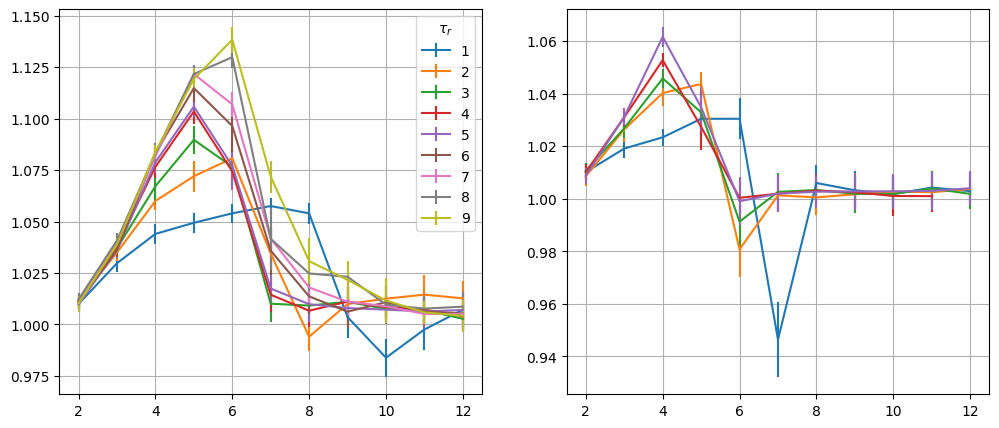

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
for idx_sd, shared_depletion in enumerate([True, False]):    
    for idx_tr, tau_reward in enumerate(taus_reward):

        cr_plot = avg_cr_idx_no_rew[idx_sd, idx_tr]

        # ax[idx_sd].plot(visual_ranges[cr_plot != 0], cr_plot[cr_plot != 0], label=f"tauR={tau_reward}")

        ax[idx_sd].errorbar(visual_ranges[cr_plot != 0], cr_plot[cr_plot != 0], yerr=std_cr_idx_no_rew[idx_sd, idx_tr][cr_plot != 0], label=f"{tau_reward}")

    ax[idx_sd].grid()
ax[0].legend(title = r"$\tau_r$")

''

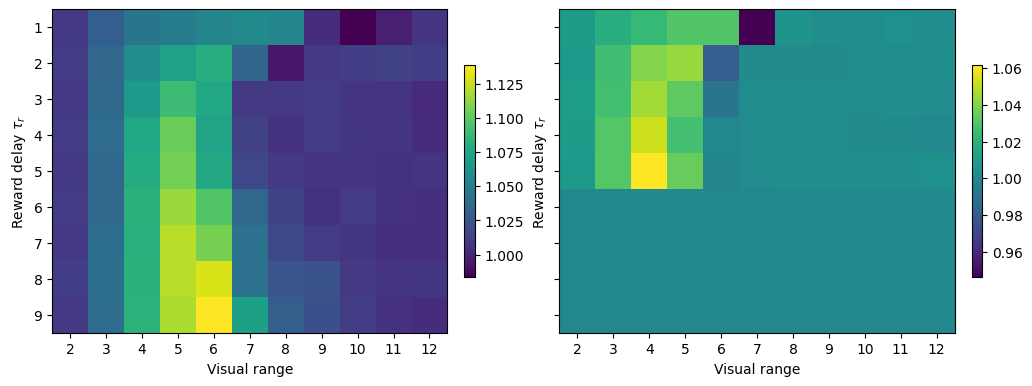

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)
for idx_sd, shared_depletion in enumerate([True, False]):

    ax[idx_sd].matshow(avg_cr_idx_no_rew[idx_sd])
    # put x axis on bottom
    ax[idx_sd].xaxis.set_ticks_position('bottom')

plt.setp(ax, 
         xticks=np.arange(len(visual_ranges)), xticklabels=visual_ranges, yticks=np.arange(len(taus_reward)), yticklabels=taus_reward,
         xlabel = "Visual range", ylabel = r"Reward delay $\tau_r$"
         )

# add colorbar to both subplots
cbar1 = fig.colorbar(ax[1].images[0], ax=ax[1], orientation='vertical', fraction=0.025, pad=0.04)
cbar2 = fig.colorbar(ax[0].images[0], ax=ax[0], orientation='vertical', fraction=0.025, pad=0.04)



;

## EXP 7_1 - tau_r

In [ ]:
from rl_opts.rl_framework.numba.agents import Foragers_efficient, run_collective
from rl_opts.rl_framework.numba.environments import CollectiveEnv
import numba
import os
import numpy as np

# Change for this run:
taus_reward = np.arange(2, 11, 1)-1 # See comment in EXP_7
visual_range = 4

num_agents = 50
max_counter = 50
runs = 1

Nt = 100; L = 50; r = 0.5
agent_step = 1
tau = 2
visual_activated = True
visual_angle=np.pi / 2 # Note that this is from the center, so from +45 to -45

# State space: [counter, any_agent_in_cone (0/1), rewarded_agent_in_cone (0/1)]
state_space = np.array([max_counter, 2, 2])

time_ep = 5000
episodes = 2000

if os.getlogin() == "gorka":
    if socket.gethostname() == "gpu-qic":
        out_dir = "/media/gorka/DATA/rl_opts_data/results_learning/collective/"
    elif socket.gethostname() == "gpu-ada-qic":
        out_dir = "/home/gorka/rl_opts/nbs/lib_nbs/develop/results/"
elif os.getlogin() == "c7051165":
    out_dir = "/scratch/c7051165/github/rl_opts/nbs/lib_nbs/develop/results/"
out_dir = os.path.join(out_dir, f"exp_7_1")
out_dir

'/media/gorka/DATA/rl_opts_data/results_learning/collective/exp_7_1'

In [ ]:
episodes = 1
time_ep = 10000
save_position_from_ep = 7500

# Loading for getting runs
file_name = f"_shared_{shared_depletion}_tau_{tau}_tauR_{taus_reward[0]+1}_vr_{visual_range}_ep_2000.npy"                           
h_matrix_path = os.path.join(out_dir, f"h_matrix"+file_name)
runs = np.load(h_matrix_path).shape[0]


dr = 0.5
n_bins = int(L / 2 / dr)
grs_tau = np.zeros((2, runs, len(taus_reward), n_bins))
cr_idx_tau = np.zeros((2, runs, len(taus_reward)))
for idx_sd, shared_depletion in enumerate([True, False]):
    for idx_vr, tau_reward in enumerate(tqdm(taus_reward)):

        file_name = f"_shared_{shared_depletion}_tau_{tau}_tauR_{tau_reward+1}_vr_{visual_range}_ep_2000.npy"
                            
        h_matrix_path = os.path.join(out_dir, 
                                    f"h_matrix"+file_name)
        try:
            mats = np.load(h_matrix_path)
        except:
            continue

        rews, posr = run_simul_collective(episodes = episodes, time_ep = time_ep, runs = runs, h_0= mats, initial_h_0=True,
                                          Nt = Nt, L = L, r = r, tau = tau, agent_step = agent_step, num_agents = num_agents,
                                    visual_range = visual_range, visual_angle = visual_angle, 
                                    shared_depletion = shared_depletion, tau_reward = tau_reward, upd_pos_method = 'RND', turn_angle = visual_angle,
                                    save_position_from_ep = save_position_from_ep)        
        
        r_c, gr_runs, cr_runs = compute_gr_all_runs(posr, L=L, dr=0.5)
        grs_tau[idx_sd, :, idx_vr, :] = gr_runs
        cr_idx_tau[idx_sd, :, idx_vr] = cr_runs

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

[Text(0.5, 0, 'r'), Text(0.5, 0, 'r')]

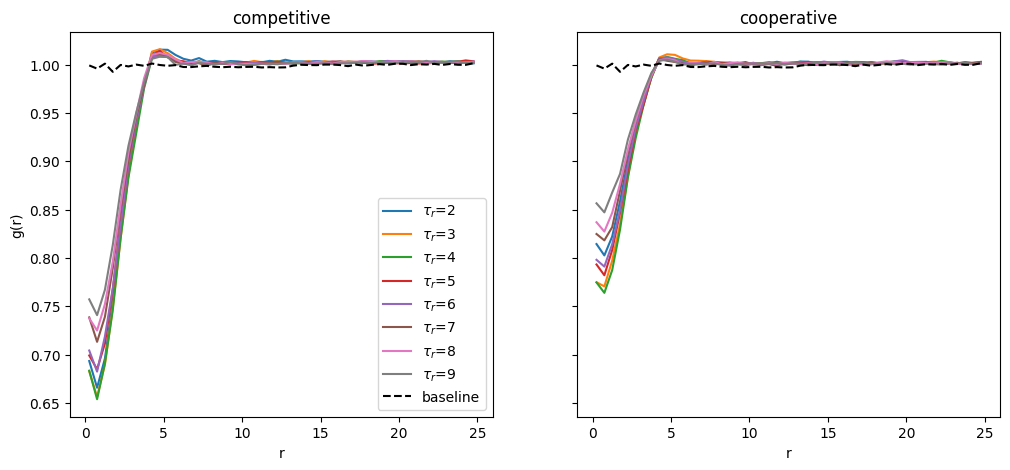

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)

for idx_sd, shared_depletion in enumerate([True, False]):
    for idx_vr, tau_reward in enumerate((taus_reward[:-1])):
        ax[idx_sd].plot(r_c, grs_tau[idx_sd, :, idx_vr].mean(0), label=fr"$\tau_r$={tau_reward+1}")
    title = 'competitive' if shared_depletion else 'cooperative'
    ax[idx_sd].set_title(title)

for i in  [0,1]:
    ax[i].plot(r_c, np.array(gr_baseline).mean(0), label="baseline", color='black', linestyle='--')

ax[0].legend()
ax[0].set_ylabel("g(r)")
plt.setp(ax, xlabel = "r")

[Text(0.5, 0, '$\\tau_r$'), Text(0.5, 0, '$\\tau_r$')]

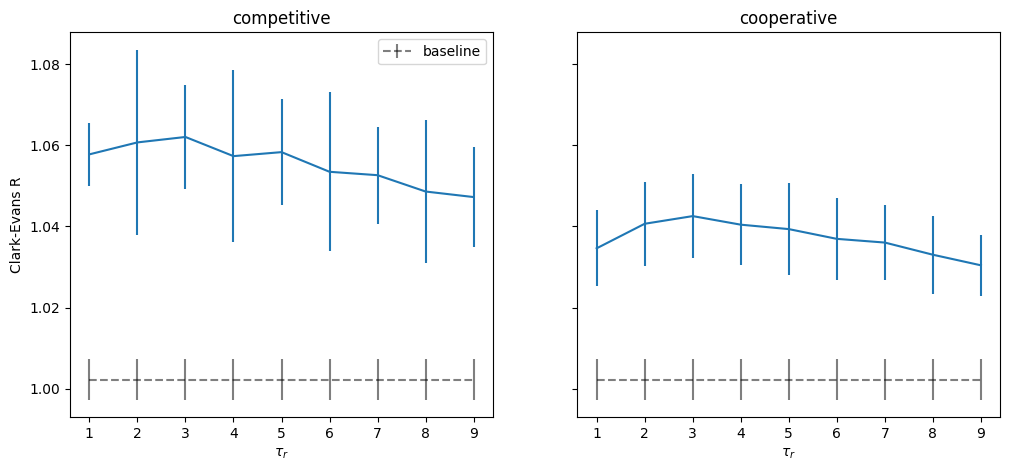

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)

for idx_sd, shared_depletion in enumerate([True, False]):
        
    ax[idx_sd].errorbar(taus_reward, cr_idx_tau[idx_sd].mean(0), yerr=cr_idx_tau[idx_sd].std(0))
    title = 'competitive' if shared_depletion else 'cooperative'
    ax[idx_sd].set_title(title)

ax[0].errorbar(taus_reward, np.ones_like(taus_reward) * np.array(cr_baseline).mean(0), yerr=np.array(cr_baseline).std(0), label="baseline", color='black', linestyle='--', alpha = 0.5)
ax[1].errorbar(taus_reward, np.ones_like(taus_reward) * np.array(cr_baseline).mean(0), yerr=np.array(cr_baseline).std(0), label="baseline", color='black', linestyle='--', alpha = 0.5)

ax[0].legend()
ax[0].set_ylabel("Clark-Evans R")
plt.setp(ax, xlabel = r"$\tau_r$")

# Inspecting trajectories

In [ ]:
# Change for this run:
taus_reward = np.arange(1, 10) 
visual_ranges = np.arange(2, 13)

# tau_rewar = 2
# visual_ranges = dnp.arange(10, 14)


num_agents = 50
max_counter = 50
runs = 1

Nt = 100; 
# We divide by 2 to allow better visibility between agents. The density stays the same
L = 50; r = 0.5
agent_step = 1
# Time delays
tau = 2
tau_reward = 1
# Visual cone
visual_activated = True
visual_angle=np.pi / 2 # Note that this is from the center, so from +45 to -45

# State space: [counter, any_agent_in_cone (0/1), rewarded_agent_in_cone (0/1)]
state_space = np.array([max_counter, 2, 2])


time_ep = 5000

if os.getlogin() == "gorka":
    if socket.gethostname() == "gpu-qic":
        out_dir = "/media/gorka/DATA/rl_opts_data/results_learning/collective/"
    elif socket.gethostname() == "gpu-ada-qic":
        out_dir = "/home/gorka/rl_opts/nbs/lib_nbs/develop/results/"
elif os.getlogin() == "c7051165":
    out_dir = "/scratch/c7051165/github/rl_opts/nbs/lib_nbs/develop/results/"
out_dir = os.path.join(out_dir, f"exp_7_3")
out_dir

'/media/gorka/DATA/rl_opts_data/results_learning/collective/exp_7_3'

In [ ]:



tau_reward = taus_reward[-1]
visual_range = visual_ranges[-1]
shared_depletion = False
episodes_learning = 10000
file_name = f"_shared_{shared_depletion}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}_ep_{episodes_learning}.npy"
                                
h_matrix_path = os.path.join(out_dir, 
                            f"h_matrix"+file_name)

mats = np.load(h_matrix_path)



In [ ]:
mats.shape

(4, 11, 50, 2, 200)

In [ ]:

agents = Foragers_efficient(num_agents, 2, state_space, initial_h_0 = True, h_0 = mats[0, -1])
env = CollectiveEnv(num_agents, Nt, L, r, tau, agent_step,
                    visual_range, visual_angle, shared_depletion, tau_reward)


In [ ]:
time_ep = 5000
save_pos_from = 3000
rews, pos, dirs = simul_loop_collective(1, time_ep, env, agents, num_agents, save_position_from_ep = save_pos_from)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# ── Subsample frames to keep the animation snappy ────────────────────────────
stride = 1                               # show every 20th timestep
frames = pos[0, -200:]        # (n_frames, num_agents, 2)
n_frames = len(frames)

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_aspect('equal')
ax.set_facecolor("#FFFFFF")
fig.patch.set_facecolor("#FFFFFF")
ax.tick_params(colors='k')
for spine in ax.spines.values():
    spine.set_edgecolor('k')

scat = ax.scatter(frames[0, :, 0], frames[0, :, 1],
                  s=25, c="#0028ab", alpha=0.85, linewidths=0)
title = ax.set_title(f't = 0', color='k', fontsize=11)

def update(frame_idx):
    pos = frames[frame_idx]
    scat.set_offsets(pos)
    title.set_text(f't = {frame_idx * stride}')
    return scat, title

anim = animation.FuncAnimation(fig, update, frames=n_frames,
                                interval=40, blit=True)
plt.close(fig)   # suppress static display

HTML(anim.to_jshtml())


# Density of agents vs target positions

In [ ]:

#### CELL FOR DENSITY

# Change for this run:
taus_reward = np.arange(1, 10)
visual_ranges = np.arange(2, 13)

num_agents = 50
max_counter = 50

Nt = 100
L = 50; r = 0.5
agent_step = 1
# Time delays
tau = 2
tau_reward = 1   # Fixed as requested
# Visual cone
visual_activated = True
visual_angle = np.pi / 2  # Note that this is from the center, so from +45 to -45

# State space: [counter, any_agent_in_cone (0/1), rewarded_agent_in_cone (0/1)]
state_space = np.array([max_counter, 2, 2])

shared_depletion = False
episodes_learning = 10000

time_ep = 5000
save_pos_from = time_ep - 1000  # save last 1000 steps

if os.getlogin() == "gorka":
    if socket.gethostname() == "gpu-qic":
        out_dir = "/media/gorka/DATA/rl_opts_data/results_learning/collective/"
    elif socket.gethostname() == "gpu-ada-qic":
        out_dir = "/home/gorka/rl_opts/nbs/lib_nbs/develop/results/"
elif os.getlogin() == "c7051165":
    out_dir = "/scratch/c7051165/github/rl_opts/nbs/lib_nbs/develop/results/"
out_dir = os.path.join(out_dir, f"exp_7_3")

# Generate random target positions (fixed across all visual ranges for comparability)
rng = np.random.default_rng(42)
target_positions = rng.uniform(0, L, size=(Nt, 2))

# Run simulation for tau_reward=1 and every available visual range
pos_all_vr = {}
for visual_range in visual_ranges:
    file_name = f"_shared_{shared_depletion}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}_ep_{episodes_learning}.npy"
    h_matrix_path = os.path.join(out_dir, f"h_matrix" + file_name)
    try:
        mats = np.load(h_matrix_path)
    except FileNotFoundError:
        print(f"File not found for vr={visual_range}, skipping.")
        continue

    agents = Foragers_efficient(num_agents, 2, state_space, initial_h_0=True, h_0=mats[0, -1])
    env = CollectiveEnv(num_agents, Nt, L, r, tau, agent_step,
                        visual_range, visual_angle, shared_depletion, tau_reward)

    rews, pos, dirs = simul_loop_collective(
        1, time_ep, env, agents, num_agents,
        save_position_from_ep=save_pos_from,
        target_positions=target_positions,
    )
    pos_all_vr[int(visual_range)] = pos  # shape: (1, 1000, num_agents, 2)
    print(f"vr={visual_range} done, pos shape: {pos.shape}")

print(f"\nCollected {len(pos_all_vr)} visual ranges: {list(pos_all_vr.keys())}")


TypeError: Can't index at [2] in [2 x i64]

In [ ]:

# Plot: 2D agent density (last 1000 steps) overlaid with target positions
n_cols = 4
vr_keys = sorted(pos_all_vr.keys())
n_vrs = len(vr_keys)
n_rows = int(np.ceil(n_vrs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

n_bins_2d = 40

for ax_idx, visual_range in enumerate(vr_keys):
    ax = axes[ax_idx]
    pos = pos_all_vr[visual_range]   # (1, 1000, num_agents, 2)

    # Flatten: all agent positions across last 1000 steps
    pos_flat = pos[0].reshape(-1, 2)  # (1000 * num_agents, 2)

    h = ax.hist2d(pos_flat[:, 0], pos_flat[:, 1],
                  bins=n_bins_2d, range=[[0, L], [0, L]],
                  cmap='Blues', density=True)
    fig.colorbar(h[3], ax=ax, fraction=0.046, pad=0.04)

    ax.scatter(target_positions[:, 0], target_positions[:, 1],
               c='red', s=12, alpha=0.8, linewidths=0, label='targets', zorder=3)

    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_aspect('equal')
    ax.set_title(f"VR = {visual_range}", fontsize=11)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

# Hide unused subplots
for ax_idx in range(n_vrs, len(axes)):
    axes[ax_idx].set_visible(False)

# Shared legend
axes[0].legend(loc='upper right', markerscale=1.5, fontsize=9)

plt.suptitle(fr"Agent density (last 1000 steps), $\tau_r = 1$, cooperative", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
